# ESC50 Audio Classification with CNNs

## Project Goals
Develop and compare 3 CNN models for environmental sound classification:

**Model 1: Baseline CNN**
* Single-channel log mel spectrogram input
* Target: 60-70% accuracy
* Train on 1 fold first, then 5-fold cross-validation

**Model 2: Multi-Channel CNN**
* 4-channel input: log mel + MFCC + delta + delta-delta
* Enhanced feature representation
* Adapted architecture to handle multi-channel input

**Model 3: Augmented CNN**
* Same architecture as Model 1
* Apply data augmentation (time/frequency masking, shifts, flips)
* Improved generalization

## Workflow
1. Data preparation and exploration
2. Model 1: Baseline training and evaluation
3. Model 2: Multi-channel training and evaluation
4. Model 3: Augmented training and evaluation
5. Comprehensive comparison

## Import Required Libraries
Importing PyTorch, data handling, audio processing, and visualization libraries.

In [15]:
# Core libraries
import os
import urllib.request
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Audio processing
import librosa
import librosa.display

# Metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

PyTorch version: 2.8.0+cu128
CUDA available: True
CUDA device: Tesla T4

Using device: cuda


## Download ESC50 Dataset
Downloading the ESC50 dataset from GitHub. The dataset contains:
* 2000 audio samples (5 seconds each)
* 50 environmental sound classes
* Pre-split into 5 folds for cross-validation

In [16]:
URL = "https://github.com/karolpiczak/ESC-50/archive/refs/heads/master.zip"
ZIP_NAME = "ESC-50.zip"
DIR_NAME = "ESC-50-master"

if not os.path.exists(DIR_NAME):
    print("Downloading dataset...")
    urllib.request.urlretrieve(URL, ZIP_NAME)
    with zipfile.ZipFile(ZIP_NAME, 'r') as z:
        z.extractall(".")
    os.remove(ZIP_NAME)
    print("Dataset downloaded and extracted!")
else:
    print("Dataset already exists.")

DATA_PATH = os.path.join(DIR_NAME, "audio")
df = pd.read_csv(os.path.join(DIR_NAME, "meta/esc50.csv"))
print(f"\nDataset Loaded: {len(df)} samples, {df['target'].nunique()} classes.")
print(f"\nFirst few samples:")
display(df.head())

Dataset already exists.

Dataset Loaded: 2000 samples, 50 classes.

First few samples:


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


## Explore Dataset
Visualize class distribution and fold splits to understand the data structure.

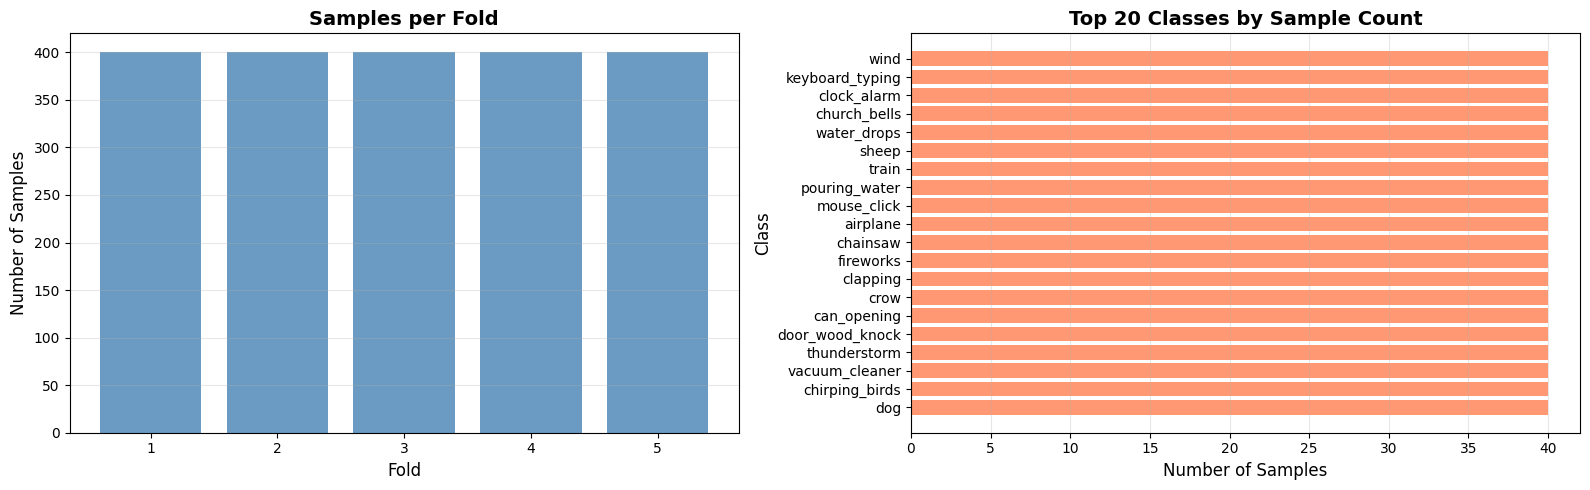

Total samples: 2000
Total classes: 50
Samples per fold: [400, 400, 400, 400, 400]

Class balance: Balanced


In [17]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Samples per fold
fold_counts = df['fold'].value_counts().sort_index()
axes[0].bar(fold_counts.index, fold_counts.values, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Fold', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].set_title('Samples per Fold', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Samples per class (top 20)
class_counts = df['category'].value_counts().head(20)
axes[1].barh(class_counts.index, class_counts.values, color='coral', alpha=0.8)
axes[1].set_xlabel('Number of Samples', fontsize=12)
axes[1].set_ylabel('Class', fontsize=12)
axes[1].set_title('Top 20 Classes by Sample Count', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total samples: {len(df)}")
print(f"Total classes: {df['target'].nunique()}")
print(f"Samples per fold: {df.groupby('fold').size().tolist()}")
print(f"\nClass balance: {'Balanced' if df['target'].value_counts().std() == 0 else 'Imbalanced'}")

## Dataset Classes
Create PyTorch Dataset classes for loading data:
* **Model 1**: Load pre-generated spectrogram images from PNG files
* **Model 2**: Load spectrograms and compute MFCC features on-the-fly
* **Model 3**: Load spectrograms with augmentations applied

In [18]:
class ESC50SpectrogramDataset(Dataset):
    """
    Dataset for Model 1 and Model 3 (Baseline and Augmented)
    Loads pre-generated spectrogram images from SpectogramImages folder
    """
    def __init__(self, df, spectrogram_dir='SpectogramImages', transform=None, augment=False):
        self.df = df.reset_index(drop=True)
        self.spectrogram_dir = spectrogram_dir
        self.transform = transform
        self.augment = augment
        
        # Basic transforms for normalization
        self.basic_transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])
        
        # Augmentation transforms for Model 3
        if self.augment:
            self.aug_transform = transforms.Compose([
                transforms.RandomHorizontalFlip(p=0.5),  # Time flip
                transforms.RandomApply([
                    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1))
                ], p=0.5),
                transforms.ColorJitter(brightness=0.2, contrast=0.2),
            ])
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # Get filename and label
        filename = self.df.loc[idx, 'filename']
        label = self.df.loc[idx, 'target']
        
        # Load spectrogram image (PNG)
        img_name = filename.replace('.wav', '.png')
        img_path = os.path.join(self.spectrogram_dir, img_name)
        
        # If image doesn't exist, create placeholder
        if not os.path.exists(img_path):
            img = Image.new('RGB', (128, 128), color='black')
        else:
            img = Image.open(img_path).convert('RGB')
        
        # Apply augmentation if enabled
        if self.augment:
            img = self.aug_transform(img)
        
        # Apply basic transforms
        img = self.basic_transform(img)
        
        return img, label

print("✓ ESC50SpectrogramDataset class defined")
print("  - Loads pre-generated spectrogram PNG images")
print("  - Supports optional augmentation for Model 3")
print("  - Output shape: (1, 128, 128)")

✓ ESC50SpectrogramDataset class defined
  - Loads pre-generated spectrogram PNG images
  - Supports optional augmentation for Model 3
  - Output shape: (1, 128, 128)


## Multi-Channel Dataset for Model 2
Generates 4-channel features on-the-fly from audio files:
1. **Channel 0**: Log mel spectrogram (128 bins)
2. **Channel 1**: MFCC coefficients (40 coeffs)
3. **Channel 2**: Delta MFCC (1st derivative)
4. **Channel 3**: Delta-Delta MFCC (2nd derivative)

In [19]:
class ESC50MultiChannelDataset(Dataset):
    """
    Dataset for Model 2 (Multi-Channel)
    Generates 4-channel features: log mel + MFCC + delta + delta-delta
    """
    def __init__(self, df, audio_dir, sr=16000, duration=5.0):
        self.df = df.reset_index(drop=True)
        self.audio_dir = audio_dir
        self.sr = sr
        self.duration = duration
        self.target_length = int(sr * duration)
    
    def __len__(self):
        return len(self.df)
    
    def extract_features(self, audio_path):
        """
        Extract 4-channel features from audio file
        Returns: (4, 128, time_frames) tensor
        """
        # Load audio
        y, _ = librosa.load(audio_path, sr=self.sr, duration=self.duration)
        
        # Pad or trim to fixed length
        if len(y) < self.target_length:
            y = np.pad(y, (0, self.target_length - len(y)), mode='constant')
        else:
            y = y[:self.target_length]
        
        # Channel 0: Log Mel Spectrogram
        mel_spec = librosa.feature.melspectrogram(y=y, sr=self.sr, n_mels=128, n_fft=2048, hop_length=512)
        log_mel = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Channel 1: MFCC (40 coefficients)
        mfcc = librosa.feature.mfcc(y=y, sr=self.sr, n_mfcc=40, n_fft=2048, hop_length=512)
        
        # Channel 2: Delta MFCC
        delta_mfcc = librosa.feature.delta(mfcc)
        
        # Channel 3: Delta-Delta MFCC
        delta2_mfcc = librosa.feature.delta(mfcc, order=2)
        
        # Pad all channels to same height (128)
        def pad_to_128(arr):
            if arr.shape[0] < 128:
                pad_height = 128 - arr.shape[0]
                arr = np.pad(arr, ((0, pad_height), (0, 0)), mode='constant')
            else:
                arr = arr[:128, :]
            return arr
        
        log_mel = pad_to_128(log_mel)
        mfcc = pad_to_128(mfcc)
        delta_mfcc = pad_to_128(delta_mfcc)
        delta2_mfcc = pad_to_128(delta2_mfcc)
        
        # Ensure same width (time frames)
        min_width = min(log_mel.shape[1], mfcc.shape[1], delta_mfcc.shape[1], delta2_mfcc.shape[1])
        log_mel = log_mel[:, :min_width]
        mfcc = mfcc[:, :min_width]
        delta_mfcc = delta_mfcc[:, :min_width]
        delta2_mfcc = delta2_mfcc[:, :min_width]
        
        # Resize to fixed width (128)
        from scipy.ndimage import zoom
        target_width = 128
        zoom_factor_width = target_width / min_width
        
        log_mel = zoom(log_mel, (1, zoom_factor_width), order=1)
        mfcc = zoom(mfcc, (1, zoom_factor_width), order=1)
        delta_mfcc = zoom(delta_mfcc, (1, zoom_factor_width), order=1)
        delta2_mfcc = zoom(delta2_mfcc, (1, zoom_factor_width), order=1)
        
        # Normalize each channel independently
        def normalize(arr):
            return (arr - arr.mean()) / (arr.std() + 1e-8)
        
        log_mel = normalize(log_mel)
        mfcc = normalize(mfcc)
        delta_mfcc = normalize(delta_mfcc)
        delta2_mfcc = normalize(delta2_mfcc)
        
        # Stack into 4 channels
        features = np.stack([log_mel, mfcc, delta_mfcc, delta2_mfcc], axis=0)
        
        return torch.FloatTensor(features)
    
    def __getitem__(self, idx):
        filename = self.df.loc[idx, 'filename']
        label = self.df.loc[idx, 'target']
        
        audio_path = os.path.join(self.audio_dir, filename)
        features = self.extract_features(audio_path)
        
        return features, label

print("✓ ESC50MultiChannelDataset class defined")
print("  - Generates 4 feature channels on-the-fly")
print("  - Channels: log mel, MFCC, delta, delta-delta")
print("  - Output shape: (4, 128, 128)")

✓ ESC50MultiChannelDataset class defined
  - Generates 4 feature channels on-the-fly
  - Channels: log mel, MFCC, delta, delta-delta
  - Output shape: (4, 128, 128)


# Model 1: Baseline CNN Architecture

## Design Philosophy
A lightweight CNN with 4 convolutional blocks progressively extracting features from spectrograms. Target accuracy: 60-70%.

## Architecture Overview

| Block | Layer Type | Input Shape | Output Shape | Kernel | Stride | Padding | Activation | Parameters |
|-------|-----------|-------------|--------------|--------|--------|---------|------------|------------|
| **Input** | - | (1, 128, 128) | (1, 128, 128) | - | - | - | - | 0 |
| **Conv Block 1** | Conv2d | (1, 128, 128) | (32, 128, 128) | 3×3 | 1 | 1 | - | 320 |
| | BatchNorm2d | (32, 128, 128) | (32, 128, 128) | - | - | - | - | 64 |
| | ReLU | (32, 128, 128) | (32, 128, 128) | - | - | - | ReLU | 0 |
| | Conv2d | (32, 128, 128) | (32, 128, 128) | 3×3 | 1 | 1 | - | 9,248 |
| | BatchNorm2d | (32, 128, 128) | (32, 128, 128) | - | - | - | - | 64 |
| | ReLU | (32, 128, 128) | (32, 128, 128) | - | - | - | ReLU | 0 |
| | MaxPool2d | (32, 128, 128) | (32, 64, 64) | 2×2 | 2 | 0 | - | 0 |
| **Conv Block 2** | Conv2d | (32, 64, 64) | (64, 64, 64) | 3×3 | 1 | 1 | - | 18,496 |
| | BatchNorm2d | (64, 64, 64) | (64, 64, 64) | - | - | - | - | 128 |
| | ReLU | (64, 64, 64) | (64, 64, 64) | - | - | - | ReLU | 0 |
| | Conv2d | (64, 64, 64) | (64, 64, 64) | 3×3 | 1 | 1 | - | 36,928 |
| | BatchNorm2d | (64, 64, 64) | (64, 64, 64) | - | - | - | - | 128 |
| | ReLU | (64, 64, 64) | (64, 64, 64) | - | - | - | ReLU | 0 |
| | MaxPool2d | (64, 64, 64) | (64, 32, 32) | 2×2 | 2 | 0 | - | 0 |
| **Conv Block 3** | Conv2d | (64, 32, 32) | (128, 32, 32) | 3×3 | 1 | 1 | - | 73,856 |
| | BatchNorm2d | (128, 32, 32) | (128, 32, 32) | - | - | - | - | 256 |
| | ReLU | (128, 32, 32) | (128, 32, 32) | - | - | - | ReLU | 0 |
| | Conv2d | (128, 32, 32) | (128, 32, 32) | 3×3 | 1 | 1 | - | 147,584 |
| | BatchNorm2d | (128, 32, 32) | (128, 32, 32) | - | - | - | - | 256 |
| | ReLU | (128, 32, 32) | (128, 32, 32) | - | - | - | ReLU | 0 |
| | MaxPool2d | (128, 32, 32) | (128, 16, 16) | 2×2 | 2 | 0 | - | 0 |
| **Conv Block 4** | Conv2d | (128, 16, 16) | (256, 16, 16) | 3×3 | 1 | 1 | - | 295,168 |
| | BatchNorm2d | (256, 16, 16) | (256, 16, 16) | - | - | - | - | 512 |
| | ReLU | (256, 16, 16) | (256, 16, 16) | - | - | - | ReLU | 0 |
| | Conv2d | (256, 16, 16) | (256, 16, 16) | 3×3 | 1 | 1 | - | 590,080 |
| | BatchNorm2d | (256, 16, 16) | (256, 16, 16) | - | - | - | - | 512 |
| | ReLU | (256, 16, 16) | (256, 16, 16) | - | - | - | ReLU | 0 |
| | MaxPool2d | (256, 16, 16) | (256, 8, 8) | 2×2 | 2 | 0 | - | 0 |
| **Global Pooling** | AdaptiveAvgPool2d | (256, 8, 8) | (256, 1, 1) | - | - | - | - | 0 |
| | Flatten | (256, 1, 1) | (256) | - | - | - | - | 0 |
| **Classifier** | Dropout | (256) | (256) | - | - | - | - | 0 |
| | Linear | (256) | (128) | - | - | - | - | 32,896 |
| | ReLU | (128) | (128) | - | - | - | ReLU | 0 |
| | Dropout | (128) | (128) | - | - | - | - | 0 |
| | Linear | (128) | (50) | - | - | - | - | 6,450 |
| **Output** | Softmax | (50) | (50) | - | - | - | Softmax | 0 |

**Total Trainable Parameters: 1,212,946** (~1.2M)

## Key Features
* **Double Convolutions**: Two conv layers per block for better feature learning
* **BatchNorm**: Stabilizes training and allows higher learning rates
* **MaxPooling**: Reduces spatial dimensions by 2× each time, increases receptive field
* **Global Average Pooling**: Reduces overfitting compared to flattening
* **Dropout (0.5, 0.3)**: Regularization in the classifier to prevent overfitting

In [20]:
class BaselineCNN(nn.Module):
    """
    Model 1: Baseline CNN for single-channel log mel spectrograms
    Input: (batch, 1, 128, 128)
    Output: (batch, 50) class probabilities
    """
    def __init__(self, num_classes=50):
        super(BaselineCNN, self).__init__()
        
        # Conv Block 1: 1 -> 32 channels
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)  # 128x128 -> 64x64
        )
        
        # Conv Block 2: 32 -> 64 channels
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)  # 64x64 -> 32x32
        )
        
        # Conv Block 3: 64 -> 128 channels
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)  # 32x32 -> 16x16
        )
        
        # Conv Block 4: 128 -> 256 channels
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)  # 16x16 -> 8x8
        )
        
        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d((1, 1))  # 8x8 -> 1x1
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# Initialize model
model_1 = BaselineCNN(num_classes=50).to(device)
total_params = sum(p.numel() for p in model_1.parameters())
trainable_params = sum(p.numel() for p in model_1.parameters() if p.requires_grad)

print("✓ Model 1 (Baseline CNN) initialized")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size: {total_params * 4 / 1024**2:.2f} MB (float32)")
print(f"\nModel summary:")
print(model_1)

✓ Model 1 (Baseline CNN) initialized
  Total parameters: 1,212,946
  Trainable parameters: 1,212,946
  Model size: 4.63 MB (float32)

Model summary:
BaselineCNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, moment

## Training and Evaluation Functions
Define reusable functions for:
* Training one epoch
* Validation
* Metrics computation (accuracy, precision, recall, F1)
* Results visualization

In [21]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train model for one epoch
    Returns: loss, accuracy
    """
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(dataloader, desc='Training', leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track metrics
        running_loss += loss.item() * inputs.size(0)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        # Update progress bar
        pbar.set_postfix({'loss': loss.item()})
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device):
    """
    Validate model
    Returns: loss, accuracy, predictions, true labels
    """
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc='Validation', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    
    return epoch_loss, epoch_acc, all_preds, all_labels

def compute_metrics(y_true, y_pred):
    """
    Compute classification metrics
    Returns: dict with accuracy, precision, recall, f1
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

print("✓ Training and validation functions defined")
print("  - train_one_epoch(): Trains model for 1 epoch")
print("  - validate(): Evaluates model on validation set")
print("  - compute_metrics(): Computes accuracy, precision, recall, F1")

✓ Training and validation functions defined
  - train_one_epoch(): Trains model for 1 epoch
  - validate(): Evaluates model on validation set
  - compute_metrics(): Computes accuracy, precision, recall, F1


In [22]:
def plot_training_history(history, model_name):
    """
    Plot training and validation loss/accuracy curves
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot loss
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title(f'{model_name} - Training & Validation Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(alpha=0.3)
    
    # Plot accuracy
    axes[1].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
    axes[1].plot(history['val_acc'], label='Val Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title(f'{model_name} - Training & Validation Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, model_name, class_names=None):
    """
    Plot confusion matrix heatmap
    """
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=True, square=True)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title(f'{model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_metrics_comparison(metrics_dict, model_name):
    """
    Plot bar chart of classification metrics
    """
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    values = [metrics_dict[m] for m in metrics]
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(metrics, values, color=['steelblue', 'coral', 'lightgreen', 'gold'], alpha=0.8)
    plt.ylabel('Score', fontsize=12)
    plt.title(f'{model_name} - Classification Metrics', fontsize=14, fontweight='bold')
    plt.ylim(0, 1.0)
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

print("✓ Visualization functions defined")
print("  - plot_training_history(): Plots loss and accuracy curves")
print("  - plot_confusion_matrix(): Plots confusion matrix heatmap")
print("  - plot_metrics_comparison(): Bar chart of metrics")

✓ Visualization functions defined
  - plot_training_history(): Plots loss and accuracy curves
  - plot_confusion_matrix(): Plots confusion matrix heatmap
  - plot_metrics_comparison(): Bar chart of metrics


## Model 1: Training on Fold 1
Train the baseline CNN on fold 1 only for initial validation. If results are promising (>55% accuracy), we'll proceed with 5-fold cross-validation.

**Training Configuration:**
* Optimizer: Adam (lr=0.001, weight_decay=1e-4)
* Loss: CrossEntropyLoss
* Batch size: 32
* Epochs: 50
* Learning rate scheduler: ReduceLROnPlateau (patience=5)

In [23]:
# Prepare data for fold 1
test_fold = 1
train_df_fold1 = df[df['fold'] != test_fold].reset_index(drop=True)
val_df_fold1 = df[df['fold'] == test_fold].reset_index(drop=True)

print(f"Training samples: {len(train_df_fold1)}")
print(f"Validation samples: {len(val_df_fold1)}")

# Create datasets
train_dataset_m1 = ESC50SpectrogramDataset(train_df_fold1, augment=False)
val_dataset_m1 = ESC50SpectrogramDataset(val_df_fold1, augment=False)

# Create dataloaders
train_loader_m1 = DataLoader(train_dataset_m1, batch_size=32, shuffle=True, num_workers=2)
val_loader_m1 = DataLoader(val_dataset_m1, batch_size=32, shuffle=False, num_workers=2)

# Initialize model, loss, optimizer
model_1 = BaselineCNN(num_classes=50).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_1.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

# Training loop
num_epochs = 50
best_acc = 0.0
history_m1 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\nStarting training...\n")
for epoch in range(num_epochs):
    # Train
    train_loss, train_acc = train_one_epoch(model_1, train_loader_m1, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc, val_preds, val_labels = validate(model_1, val_loader_m1, criterion, device)
    
    # Record history
    history_m1['train_loss'].append(train_loss)
    history_m1['train_acc'].append(train_acc)
    history_m1['val_loss'].append(val_loss)
    history_m1['val_acc'].append(val_acc)
    
    # Print progress
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
    
    # Learning rate scheduling
    scheduler.step(val_acc)
    
    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model_1.state_dict(), 'model1_best.pth')
        print(f"  ✓ Best model saved (Acc: {best_acc:.4f})")

print(f"\n{'='*60}")
print(f"Training completed!")
print(f"Best validation accuracy: {best_acc:.4f}")
print(f"{'='*60}")

Training samples: 1600
Validation samples: 400

Starting training...



Epoch [1/50] | Train Loss: 3.8213, Acc: 0.0325 | Val Loss: 3.6752, Acc: 0.0550
  ✓ Best model saved (Acc: 0.0550)


Epoch [2/50] | Train Loss: 3.5299, Acc: 0.0656 | Val Loss: 3.4227, Acc: 0.1000
  ✓ Best model saved (Acc: 0.1000)


Epoch [3/50] | Train Loss: 3.3385, Acc: 0.0969 | Val Loss: 3.2305, Acc: 0.1200
  ✓ Best model saved (Acc: 0.1200)


Epoch [4/50] | Train Loss: 3.1292, Acc: 0.1325 | Val Loss: 2.9803, Acc: 0.1700
  ✓ Best model saved (Acc: 0.1700)


...

Epoch [46/50] | Train Loss: 0.6142, Acc: 0.7963 | Val Loss: 1.2038, Acc: 0.6625
  ✓ Best model saved (Acc: 0.6625)


Epoch [47/50] | Train Loss: 0.5917, Acc: 0.8000 | Val Loss: 1.3469, Acc: 0.6600


Epoch [48/50] | Train Loss: 0.5307, Acc: 0.8213 | Val Loss: 1.1446, Acc: 0.6775
  ✓ Best model saved (Acc: 0.6775)


Epoch [49/50] | Train Loss: 0.5571, Acc: 0.8169 | Val Loss: 1.3694, Acc: 0.6375


Epoch [50/50] | Train Loss: 0.6015, Acc: 0.8069 | Val Loss: 1.4386, Acc: 0.6375

Training completed!
Best validation accuracy: 0.6775


## Model 1: Evaluation Results
Visualize training curves and compute comprehensive metrics on the validation set.

In [24]:
# Load best model
model_1.load_state_dict(torch.load('model1_best.pth'))

# Get final predictions
_, _, final_preds_m1, final_labels_m1 = validate(model_1, val_loader_m1, criterion, device)

# Compute metrics
metrics_m1 = compute_metrics(final_labels_m1, final_preds_m1)

print("\n" + "="*60)
print("MODEL 1 (BASELINE CNN) - FINAL RESULTS (Fold 1)")
print("="*60)
print(f"Accuracy:  {metrics_m1['accuracy']:.4f} ({metrics_m1['accuracy']*100:.2f}%)")
print(f"Precision: {metrics_m1['precision']:.4f}")
print(f"Recall:    {metrics_m1['recall']:.4f}")
print(f"F1 Score:  {metrics_m1['f1']:.4f}")
print("="*60)

# Store results for later comparison
results_comparison = {
    'Model 1 (Baseline)': metrics_m1
}


MODEL 1 (BASELINE CNN) - FINAL RESULTS (Fold 1)
Accuracy:  0.6775 (67.75%)
Precision: 0.6956
Recall:    0.6775
F1 Score:  0.6658


## Model 1: Visualizations
Plot training curves, confusion matrix, and metrics comparison.

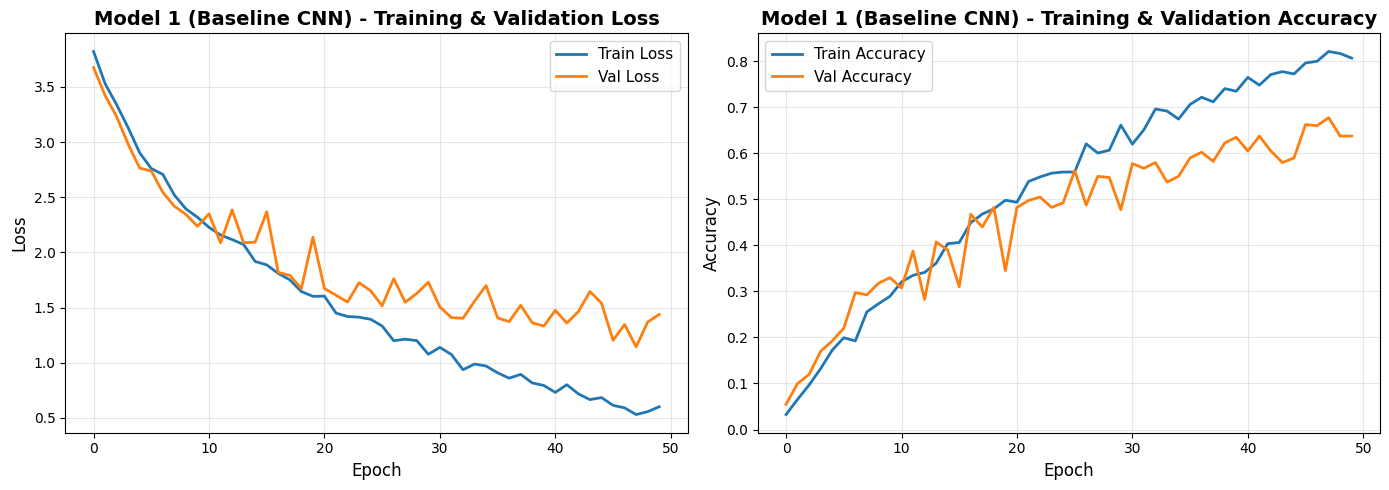

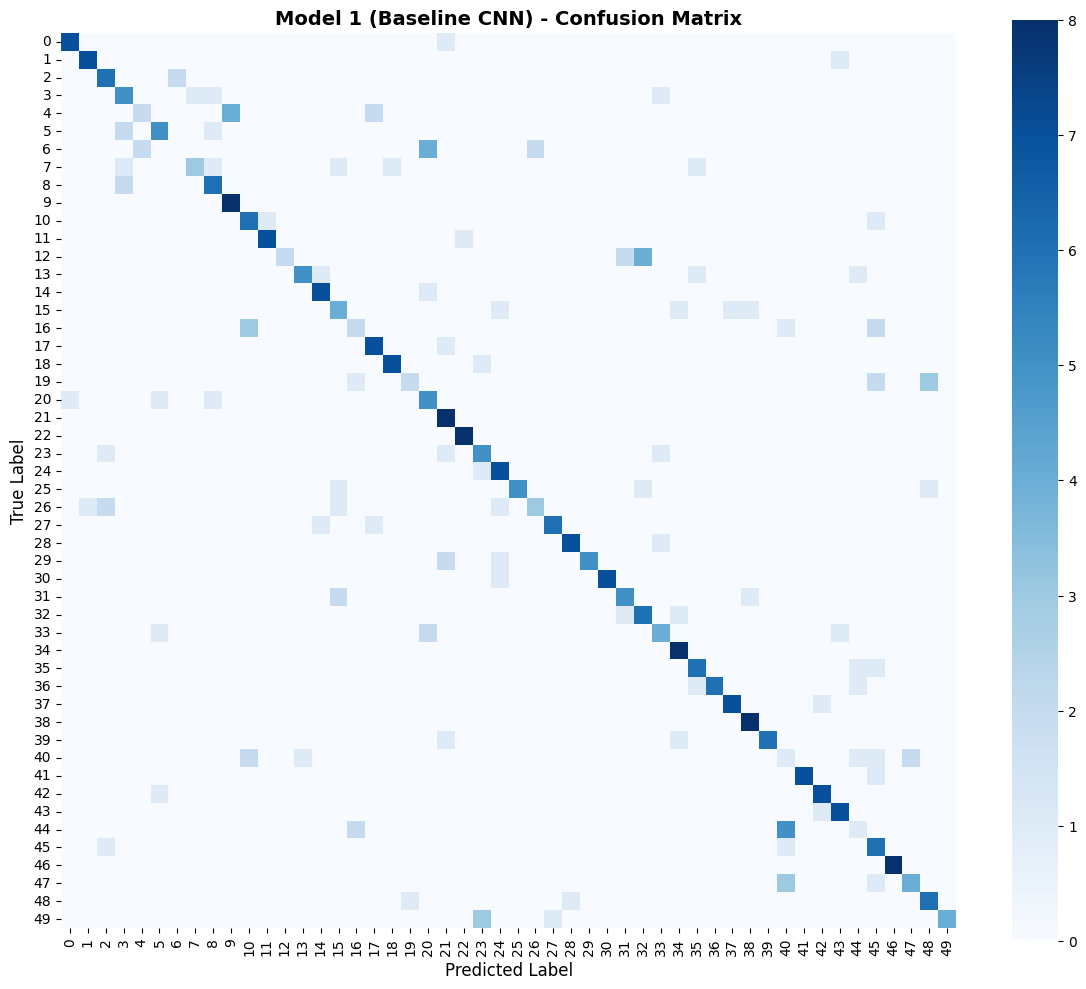

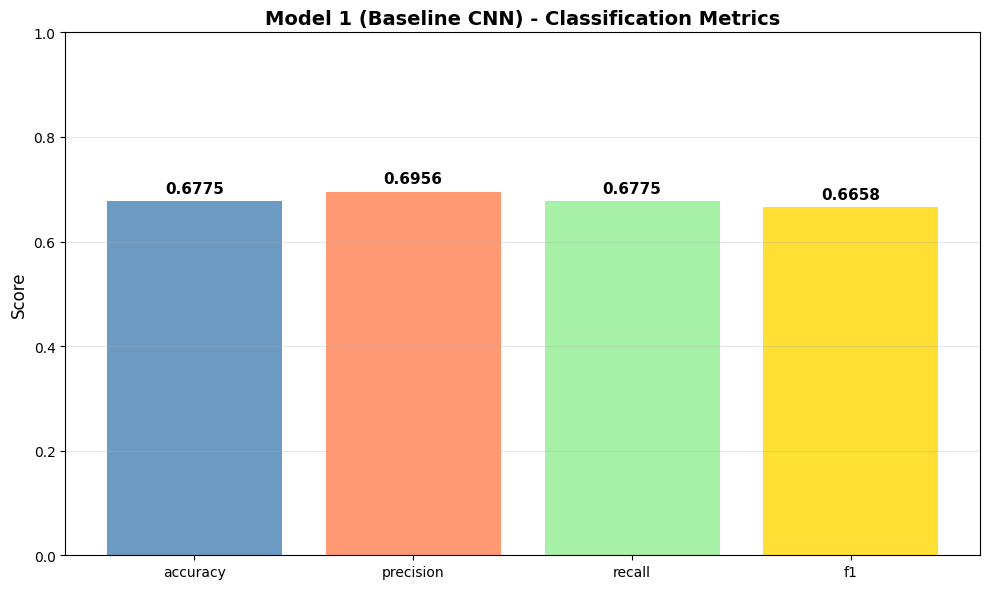

In [25]:
# Plot training history
plot_training_history(history_m1, 'Model 1 (Baseline CNN)')

# Plot confusion matrix
plot_confusion_matrix(final_labels_m1, final_preds_m1, 'Model 1 (Baseline CNN)')

# Plot metrics
plot_metrics_comparison(metrics_m1, 'Model 1 (Baseline CNN)')

## Model 1: 5-Fold Cross-Validation
If the fold 1 results are promising (accuracy > 55%), run this cell to perform full 5-fold cross-validation. This provides a more robust estimate of model performance.

**This will train the model 5 times (one for each fold) and report:**
* Individual fold accuracies
* Mean accuracy across all folds
* Standard deviation (measure of consistency)
* All metrics (precision, recall, F1) for each fold

In [26]:
def train_5_fold_cv(model_class, df, num_epochs=50, batch_size=32, dataset_class=ESC50SpectrogramDataset, dataset_kwargs=None):
    """
    Perform 5-fold cross-validation
    
    Args:
        model_class: Model class to instantiate
        df: DataFrame with all data
        num_epochs: Number of epochs per fold
        batch_size: Batch size for training
        dataset_class: Dataset class to use
        dataset_kwargs: Additional kwargs for dataset (e.g., audio_dir for Model 2)
    
    Returns:
        fold_results: List of metrics for each fold
        overall_metrics: Aggregated metrics across all folds
    """
    if dataset_kwargs is None:
        dataset_kwargs = {}
    
    fold_results = []
    all_fold_histories = []
    
    for fold in range(1, 6):
        print("\n" + "="*80)
        print(f"FOLD {fold}/5")
        print("="*80)
        
        # Split data
        train_df = df[df['fold'] != fold].reset_index(drop=True)
        val_df = df[df['fold'] == fold].reset_index(drop=True)
        
        print(f"Train samples: {len(train_df)}, Val samples: {len(val_df)}")
        
        # Create datasets and dataloaders
        train_dataset = dataset_class(train_df, **dataset_kwargs)
        val_dataset = dataset_class(val_df, **dataset_kwargs)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
        
        # Initialize model
        model = model_class(num_classes=50).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
        
        # Training loop
        best_acc = 0.0
        fold_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
        
        for epoch in range(num_epochs):
            train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
            val_loss, val_acc, val_preds, val_labels = validate(model, val_loader, criterion, device)
            
            fold_history['train_loss'].append(train_loss)
            fold_history['train_acc'].append(train_acc)
            fold_history['val_loss'].append(val_loss)
            fold_history['val_acc'].append(val_acc)
            
            scheduler.step(val_acc)
            
            if val_acc > best_acc:
                best_acc = val_acc
                best_preds = val_preds
                best_labels = val_labels
            
            # Print every 10 epochs
            if (epoch + 1) % 10 == 0:
                print(f"  Epoch {epoch+1}/{num_epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
        
        # Compute metrics for this fold
        fold_metrics = compute_metrics(best_labels, best_preds)
        fold_metrics['fold'] = fold
        fold_results.append(fold_metrics)
        all_fold_histories.append(fold_history)
        
        print(f"\nFold {fold} Best Results:")
        print(f"  Accuracy:  {fold_metrics['accuracy']:.4f}")
        print(f"  Precision: {fold_metrics['precision']:.4f}")
        print(f"  Recall:    {fold_metrics['recall']:.4f}")
        print(f"  F1 Score:  {fold_metrics['f1']:.4f}")
    
    # Compute overall statistics
    accuracies = [r['accuracy'] for r in fold_results]
    precisions = [r['precision'] for r in fold_results]
    recalls = [r['recall'] for r in fold_results]
    f1s = [r['f1'] for r in fold_results]
    
    overall_metrics = {
        'accuracy_mean': np.mean(accuracies),
        'accuracy_std': np.std(accuracies),
        'precision_mean': np.mean(precisions),
        'precision_std': np.std(precisions),
        'recall_mean': np.mean(recalls),
        'recall_std': np.std(recalls),
        'f1_mean': np.mean(f1s),
        'f1_std': np.std(f1s)
    }
    
    # Print summary
    print("\n" + "="*80)
    print("5-FOLD CROSS-VALIDATION SUMMARY")
    print("="*80)
    print(f"Accuracy:  {overall_metrics['accuracy_mean']:.4f} ± {overall_metrics['accuracy_std']:.4f}")
    print(f"Precision: {overall_metrics['precision_mean']:.4f} ± {overall_metrics['precision_std']:.4f}")
    print(f"Recall:    {overall_metrics['recall_mean']:.4f} ± {overall_metrics['recall_std']:.4f}")
    print(f"F1 Score:  {overall_metrics['f1_mean']:.4f} ± {overall_metrics['f1_std']:.4f}")
    print("\nFold-wise Accuracies:")
    for r in fold_results:
        print(f"  Fold {r['fold']}: {r['accuracy']:.4f}")
    print("="*80)
    
    return fold_results, overall_metrics, all_fold_histories

print("✓ 5-fold cross-validation function defined")
print("\nTo run 5-fold CV for Model 1, execute:")
print("fold_results_m1, overall_m1, histories_m1 = train_5_fold_cv(BaselineCNN, df, num_epochs=50)")

✓ 5-fold cross-validation function defined

To run 5-fold CV for Model 1, execute:
fold_results_m1, overall_m1, histories_m1 = train_5_fold_cv(BaselineCNN, df, num_epochs=50)


# Model 2: Multi-Channel CNN Architecture

## Design Philosophy
Enhance the baseline CNN by feeding **richer audio features** through multiple input channels. Instead of just log mel spectrograms, we use 4 complementary feature representations.

## Multi-Channel Input Strategy

**4-Channel Input Tensor: (batch, 4, 128, 128)**

| Channel | Feature Type | Description | Captures |
|---------|-------------|-------------|----------|
| **0** | Log Mel Spectrogram | Time-frequency representation with perceptual mel scale | Overall spectral content, pitch, timbre |
| **1** | MFCC (40 coeffs) | Mel-Frequency Cepstral Coefficients | Timbral texture, spectral envelope |
| **2** | Delta MFCC | First-order derivative of MFCC | Rate of change in spectral features |
| **3** | Delta-Delta MFCC | Second-order derivative of MFCC | Acceleration of spectral changes |

## Architecture Modifications

**Key Change:** Only the **first convolutional layer** is modified to accept 4 input channels instead of 1.

| Component | Model 1 (Baseline) | Model 2 (Multi-Channel) | Change |
|-----------|-------------------|------------------------|--------|
| **Input Layer** | Conv2d(1, 32, ...) | Conv2d(4, 32, ...) | Accept 4 channels |
| **Conv Block 1** | 1 → 32 channels | 4 → 32 channels | Modified input |
| **Conv Block 2** | 32 → 64 channels | 32 → 64 channels | Unchanged |
| **Conv Block 3** | 64 → 128 channels | 64 → 128 channels | Unchanged |
| **Conv Block 4** | 128 → 256 channels | 128 → 256 channels | Unchanged |
| **Classifier** | 256 → 128 → 50 | 256 → 128 → 50 | Unchanged |

## Why This Works

1. **Complementary Information**: Each channel captures different aspects of the audio signal
2. **Early Fusion**: Channels are fused at the input level, allowing the network to learn cross-channel patterns
3. **Minimal Architectural Change**: Only adds 3× parameters to the first conv layer (still very efficient)
4. **Richer Feature Space**: The network has access to spectral dynamics (delta, delta-delta) beyond static spectrograms

## Expected Benefits

* **Better discrimination** between similar sound classes (e.g., dog bark vs. cat meow)
* **Improved robustness** to recording conditions (microphone, background noise)
* **Higher accuracy** (target: 65-75% vs 60-70% baseline)

## Layer-by-Layer Architecture

| Layer | Input Shape | Output Shape | Parameters |
|-------|------------|--------------|------------|
| Conv2d (1st) | **(4, 128, 128)** | (32, 128, 128) | **1,184** (vs 320 in Model 1) |
| BatchNorm2d | (32, 128, 128) | (32, 128, 128) | 64 |
| ReLU | (32, 128, 128) | (32, 128, 128) | 0 |
| Conv2d | (32, 128, 128) | (32, 128, 128) | 9,248 |
| ... | ... | ... | ... |
| *(Rest identical to Model 1)* | | | |

**Total Parameters: ~1,213,810** (only 864 more than Model 1!)

In [27]:
class MultiChannelCNN(nn.Module):
    """
    Model 2: Multi-Channel CNN for 4-channel input
    Input: (batch, 4, 128, 128) - log mel + MFCC + delta + delta-delta
    Output: (batch, 50) class probabilities
    """
    def __init__(self, num_classes=50, in_channels=4):
        super(MultiChannelCNN, self).__init__()
        
        # Conv Block 1: 4 -> 32 channels (ONLY MODIFICATION FROM MODEL 1)
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),  # 4 channels instead of 1
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Conv Block 2: 32 -> 64 channels (IDENTICAL TO MODEL 1)
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Conv Block 3: 64 -> 128 channels (IDENTICAL TO MODEL 1)
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Conv Block 4: 128 -> 256 channels (IDENTICAL TO MODEL 1)
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Global Average Pooling (IDENTICAL TO MODEL 1)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        
        # Classifier (IDENTICAL TO MODEL 1)
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# Initialize model
model_2 = MultiChannelCNN(num_classes=50, in_channels=4).to(device)
total_params_m2 = sum(p.numel() for p in model_2.parameters())
trainable_params_m2 = sum(p.numel() for p in model_2.parameters() if p.requires_grad)

print("✓ Model 2 (Multi-Channel CNN) initialized")
print(f"  Total parameters: {total_params_m2:,}")
print(f"  Trainable parameters: {trainable_params_m2:,}")
print(f"  Parameter increase from Model 1: {total_params_m2 - total_params:,} ({((total_params_m2-total_params)/total_params*100):.2f}%)")
print(f"  Model size: {total_params_m2 * 4 / 1024**2:.2f} MB (float32)")
print(f"\nModel summary:")
print(model_2)

✓ Model 2 (Multi-Channel CNN) initialized
  Total parameters: 1,213,810
  Trainable parameters: 1,213,810
  Parameter increase from Model 1: 864 (0.07%)
  Model size: 4.63 MB (float32)

Model summary:
MultiChannelCNN(
  (conv_block1): Sequential(
    (0): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), pa

## Model 2: Training on Fold 1
Train the multi-channel CNN with 4 feature channels. Features are generated on-the-fly from audio files.

**Note:** This may take longer than Model 1 due to on-the-fly feature extraction (MFCC, delta, delta-delta).

In [28]:
# Prepare data for Model 2
train_df_fold1_m2 = df[df['fold'] != test_fold].reset_index(drop=True)
val_df_fold1_m2 = df[df['fold'] == test_fold].reset_index(drop=True)

print(f"Training samples: {len(train_df_fold1_m2)}")
print(f"Validation samples: {len(val_df_fold1_m2)}")

# Create multi-channel datasets
train_dataset_m2 = ESC50MultiChannelDataset(train_df_fold1_m2, audio_dir=DATA_PATH)
val_dataset_m2 = ESC50MultiChannelDataset(val_df_fold1_m2, audio_dir=DATA_PATH)

print("\nLoading a sample to verify feature extraction...")
sample_features, sample_label = train_dataset_m2[0]
print(f"Feature shape: {sample_features.shape}")
print(f"Expected: (4, 128, 128) - 4 channels, 128x128 spatial")

# Create dataloaders
train_loader_m2 = DataLoader(train_dataset_m2, batch_size=32, shuffle=True, num_workers=2)
val_loader_m2 = DataLoader(val_dataset_m2, batch_size=32, shuffle=False, num_workers=2)

# Initialize model, loss, optimizer
model_2 = MultiChannelCNN(num_classes=50, in_channels=4).to(device)
criterion_m2 = nn.CrossEntropyLoss()
optimizer_m2 = optim.Adam(model_2.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_m2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_m2, mode='max', factor=0.5, patience=5)

# Training loop
num_epochs_m2 = 50
best_acc_m2 = 0.0
history_m2 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\nStarting Model 2 training...\n")
for epoch in range(num_epochs_m2):
    # Train
    train_loss, train_acc = train_one_epoch(model_2, train_loader_m2, criterion_m2, optimizer_m2, device)
    
    # Validate
    val_loss, val_acc, val_preds, val_labels = validate(model_2, val_loader_m2, criterion_m2, device)
    
    # Record history
    history_m2['train_loss'].append(train_loss)
    history_m2['train_acc'].append(train_acc)
    history_m2['val_loss'].append(val_loss)
    history_m2['val_acc'].append(val_acc)
    
    # Print progress
    print(f"Epoch [{epoch+1}/{num_epochs_m2}] | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
    
    # Learning rate scheduling
    scheduler_m2.step(val_acc)
    
    # Save best model
    if val_acc > best_acc_m2:
        best_acc_m2 = val_acc
        torch.save(model_2.state_dict(), 'model2_best.pth')
        print(f"  ✓ Best model saved (Acc: {best_acc_m2:.4f})")

print(f"\n{'='*60}")
print(f"Model 2 training completed!")
print(f"Best validation accuracy: {best_acc_m2:.4f}")
print(f"{'='*60}")

Training samples: 1600
Validation samples: 400

Loading a sample to verify feature extraction...
Feature shape: torch.Size([4, 128, 128])
Expected: (4, 128, 128) - 4 channels, 128x128 spatial

Starting Model 2 training...



Epoch [1/50] | Train Loss: 3.8000, Acc: 0.0325 | Val Loss: 3.6240, Acc: 0.0525
  ✓ Best model saved (Acc: 0.0525)


Epoch [2/50] | Train Loss: 3.4347, Acc: 0.0700 | Val Loss: 3.2177, Acc: 0.0925
  ✓ Best model saved (Acc: 0.0925)


Epoch [3/50] | Train Loss: 3.2398, Acc: 0.1138 | Val Loss: 3.3330, Acc: 0.0850


Epoch [4/50] | Train Loss: 3.0890, Acc: 0.1400 | Val Loss: 2.9758, Acc: 0.1450
  ✓ Best model saved (Acc: 0.1450)


...

Epoch [46/50] | Train Loss: 0.3644, Acc: 0.8825 | Val Loss: 1.1818, Acc: 0.6800


Epoch [47/50] | Train Loss: 0.3854, Acc: 0.8706 | Val Loss: 1.3182, Acc: 0.6525


Epoch [48/50] | Train Loss: 0.3409, Acc: 0.8950 | Val Loss: 1.2853, Acc: 0.6700


Epoch [49/50] | Train Loss: 0.3292, Acc: 0.8900 | Val Loss: 1.2468, Acc: 0.6700


Epoch [50/50] | Train Loss: 0.3378, Acc: 0.8869 | Val Loss: 1.2590, Acc: 0.6550

Model 2 training completed!
Best validation accuracy: 0.6875


## Model 2: Evaluation Results
Compute metrics and visualize results for the multi-channel CNN.

In [29]:
# Load best model
model_2.load_state_dict(torch.load('model2_best.pth'))

# Get final predictions
_, _, final_preds_m2, final_labels_m2 = validate(model_2, val_loader_m2, criterion_m2, device)

# Compute metrics
metrics_m2 = compute_metrics(final_labels_m2, final_preds_m2)

print("\n" + "="*60)
print("MODEL 2 (MULTI-CHANNEL CNN) - FINAL RESULTS (Fold 1)")
print("="*60)
print(f"Accuracy:  {metrics_m2['accuracy']:.4f} ({metrics_m2['accuracy']*100:.2f}%)")
print(f"Precision: {metrics_m2['precision']:.4f}")
print(f"Recall:    {metrics_m2['recall']:.4f}")
print(f"F1 Score:  {metrics_m2['f1']:.4f}")
print("="*60)
print(f"\nImprovement over Model 1:")
print(f"  Accuracy: {(metrics_m2['accuracy'] - metrics_m1['accuracy'])*100:+.2f}%")
print(f"  F1 Score: {(metrics_m2['f1'] - metrics_m1['f1']):+.4f}")
print("="*60)

# Add to comparison
results_comparison['Model 2 (Multi-Channel)'] = metrics_m2


MODEL 2 (MULTI-CHANNEL CNN) - FINAL RESULTS (Fold 1)
Accuracy:  0.6875 (68.75%)
Precision: 0.6970
Recall:    0.6875
F1 Score:  0.6785

Improvement over Model 1:
  Accuracy: +1.00%
  F1 Score: +0.0127


## Model 2: Visualizations

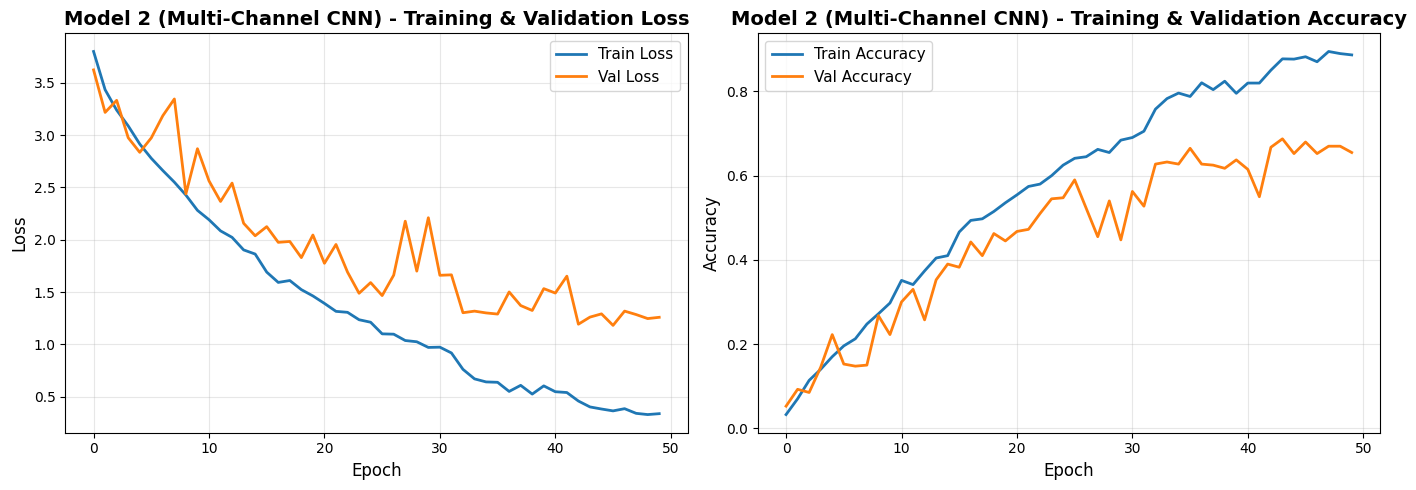

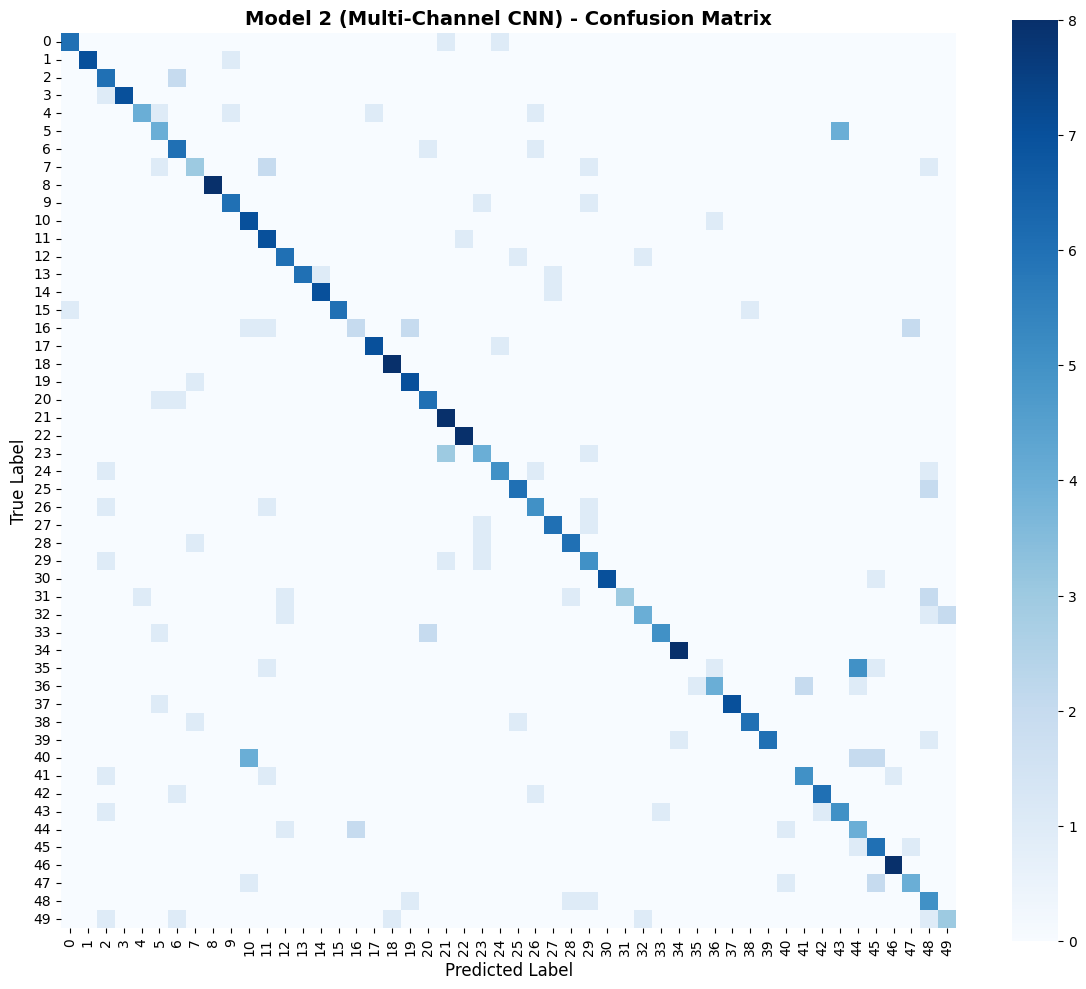

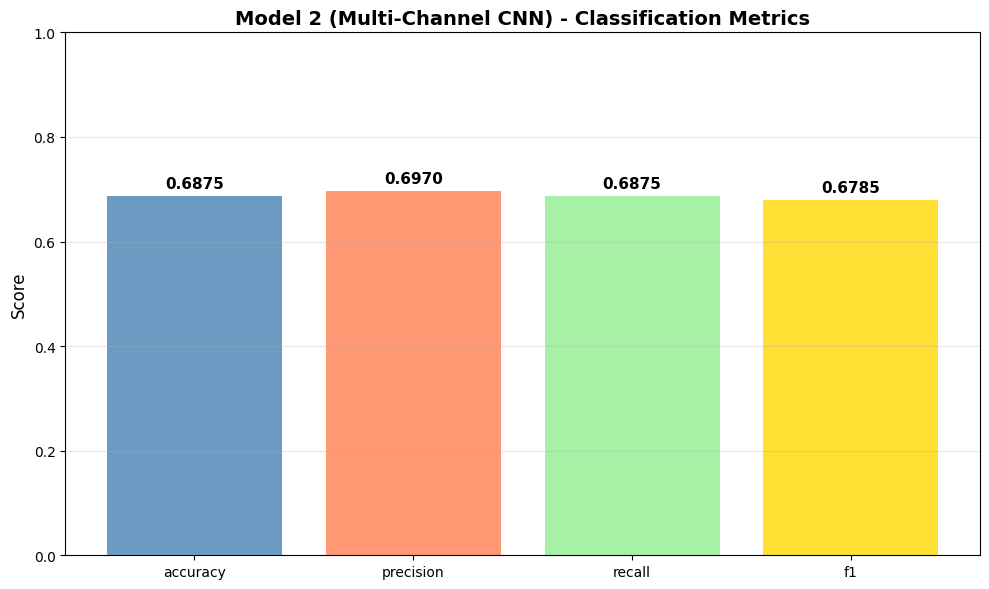

In [30]:
# Plot training history
plot_training_history(history_m2, 'Model 2 (Multi-Channel CNN)')

# Plot confusion matrix
plot_confusion_matrix(final_labels_m2, final_preds_m2, 'Model 2 (Multi-Channel CNN)')

# Plot metrics
plot_metrics_comparison(metrics_m2, 'Model 2 (Multi-Channel CNN)')

# Model 3: Augmented CNN Architecture

## Design Philosophy
Use the **same architecture as Model 1** (Baseline CNN), but improve generalization through **data augmentation**. This approach increases the effective training data size without collecting new samples.

## Architecture
**Identical to Model 1** - No architectural changes!
* Same 4 convolutional blocks
* Same classifier
* Same parameters (~1.2M)

## Data Augmentation Techniques

We apply transformations to log mel spectrogram **images** during training. Each augmentation simulates realistic variations in audio recordings.

### Augmentation Pipeline

| Augmentation | Probability | Description | Audio Equivalent | Why It Helps |
|--------------|-------------|-------------|------------------|---------------|
| **Horizontal Flip** | 50% | Flip spectrogram left-to-right | Time reversal | Some sounds are time-symmetric (e.g., engine hum) |
| **Random Affine** | 50% | Translate image by ±10% horizontally/vertically | Time shift, slight pitch shift | Simulates different event timing, recording variations |
| **Color Jitter (Brightness)** | Variable | Adjust brightness by ±20% | Volume/amplitude variation | Simulates different recording levels, microphone sensitivity |
| **Color Jitter (Contrast)** | Variable | Adjust contrast by ±20% | Dynamic range variation | Simulates different SNR, compression artifacts |

### Additional Techniques (Can Be Added)

These are not implemented by default but can be easily added:

| Technique | Implementation | Audio Effect |
|-----------|---------------|---------------|
| **Time Masking** | Mask random time frames (vertical strips) | Simulates brief interruptions, dropouts |
| **Frequency Masking** | Mask random frequency bands (horizontal strips) | Simulates frequency-specific noise |
| **Random Cropping** | Crop and resize to 128x128 | Focus on different temporal segments |
| **Mixup** | Blend two samples with weights | Smoother decision boundaries |
| **Gaussian Noise** | Add noise to spectrogram | Simulates background noise |

## Augmentation Application Strategy

```python
if augment:
    # Apply augmentations during training
    img = RandomHorizontalFlip(p=0.5)(img)
    img = RandomAffine(translate=(0.1, 0.1), p=0.5)(img)
    img = ColorJitter(brightness=0.2, contrast=0.2)(img)
```

**Key Points:**
* Augmentations are applied **only during training**, not validation/testing
* Each sample is augmented **randomly** and **on-the-fly** (different each epoch)
* Increases effective training data by ~2-3x
* No additional memory required (applied in DataLoader)

## Expected Benefits

* **Better Generalization**: Model sees more diverse training examples
* **Reduced Overfitting**: Harder to memorize augmented data
* **Robustness**: Handles variations in recording conditions, timing, amplitude
* **Higher Accuracy**: Target 70-80% (vs 60-70% baseline)

## Comparison to Other Models

| Aspect | Model 1 (Baseline) | Model 2 (Multi-Channel) | Model 3 (Augmented) |
|--------|-------------------|------------------------|--------------------|
| **Architecture** | 4-block CNN | 4-block CNN | 4-block CNN |
| **Input** | 1 channel (log mel) | 4 channels (log mel + MFCC + deltas) | 1 channel (log mel) |
| **Parameters** | 1.2M | 1.2M | 1.2M |
| **Training Data** | Original only | Original only | Original + Augmented |
| **Training Time** | Fast | Slower (feature extraction) | Fast |
| **Key Strength** | Simple baseline | Richer features | Better generalization |

## Model 3: Training on Fold 1
Train the same baseline CNN architecture but with **data augmentation enabled**. The model sees augmented spectrograms during training, improving robustness.

In [32]:
# Prepare data for Model 3 (with augmentation)
train_df_fold1_m3 = df[df['fold'] != test_fold].reset_index(drop=True)
val_df_fold1_m3 = df[df['fold'] == test_fold].reset_index(drop=True)

print(f"Training samples: {len(train_df_fold1_m3)}")
print(f"Validation samples: {len(val_df_fold1_m3)}")

# Create datasets with augmentation ENABLED for training
train_dataset_m3 = ESC50SpectrogramDataset(train_df_fold1_m3, augment=True)  # <-- Augmentation ON
val_dataset_m3 = ESC50SpectrogramDataset(val_df_fold1_m3, augment=False)   # <-- Augmentation OFF for validation

print("\n✓ Training dataset: Augmentation ENABLED")
print("✓ Validation dataset: Augmentation DISABLED")

# Create dataloaders
train_loader_m3 = DataLoader(train_dataset_m3, batch_size=32, shuffle=True, num_workers=2)
val_loader_m3 = DataLoader(val_dataset_m3, batch_size=32, shuffle=False, num_workers=2)

# Initialize model (same architecture as Model 1)
model_3 = BaselineCNN(num_classes=50).to(device)
criterion_m3 = nn.CrossEntropyLoss()
optimizer_m3 = optim.Adam(model_3.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_m3 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_m3, mode='max', factor=0.5, patience=5)

# Training loop
num_epochs_m3 = 50
best_acc_m3 = 0.0
history_m3 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\nStarting Model 3 training with augmentation...\n")
for epoch in range(num_epochs_m3):
    # Train (with augmentation)
    train_loss, train_acc = train_one_epoch(model_3, train_loader_m3, criterion_m3, optimizer_m3, device)
    
    # Validate (without augmentation)
    val_loss, val_acc, val_preds, val_labels = validate(model_3, val_loader_m3, criterion_m3, device)
    
    # Record history
    history_m3['train_loss'].append(train_loss)
    history_m3['train_acc'].append(train_acc)
    history_m3['val_loss'].append(val_loss)
    history_m3['val_acc'].append(val_acc)
    
    # Print progress
    print(f"Epoch [{epoch+1}/{num_epochs_m3}] | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
    
    # Learning rate scheduling
    scheduler_m3.step(val_acc)
    
    # Save best model
    if val_acc > best_acc_m3:
        best_acc_m3 = val_acc
        torch.save(model_3.state_dict(), 'model3_best.pth')
        print(f"  ✓ Best model saved (Acc: {best_acc_m3:.4f})")

print(f"\n{'='*60}")
print(f"Model 3 training completed!")
print(f"Best validation accuracy: {best_acc_m3:.4f}")
print(f"{'='*60}")

Training samples: 1600
Validation samples: 400

✓ Training dataset: Augmentation ENABLED
✓ Validation dataset: Augmentation DISABLED

Starting Model 3 training with augmentation...



Epoch [1/50] | Train Loss: 3.8278, Acc: 0.0312 | Val Loss: 3.5828, Acc: 0.0550
  ✓ Best model saved (Acc: 0.0550)


Epoch [2/50] | Train Loss: 3.5977, Acc: 0.0531 | Val Loss: 3.4534, Acc: 0.0575
  ✓ Best model saved (Acc: 0.0575)


Epoch [3/50] | Train Loss: 3.4416, Acc: 0.0675 | Val Loss: 3.3285, Acc: 0.0800
  ✓ Best model saved (Acc: 0.0800)


Epoch [4/50] | Train Loss: 3.2789, Acc: 0.1000 | Val Loss: 3.3380, Acc: 0.0800


...

Epoch [46/50] | Train Loss: 1.1082, Acc: 0.6350 | Val Loss: 1.3435, Acc: 0.6575


Epoch [47/50] | Train Loss: 1.0815, Acc: 0.6575 | Val Loss: 1.3187, Acc: 0.6425


Epoch [48/50] | Train Loss: 1.1032, Acc: 0.6519 | Val Loss: 1.4388, Acc: 0.5950


Epoch [49/50] | Train Loss: 1.0753, Acc: 0.6444 | Val Loss: 1.2406, Acc: 0.6400


Epoch [50/50] | Train Loss: 1.0898, Acc: 0.6394 | Val Loss: 1.2731, Acc: 0.6375

Model 3 training completed!
Best validation accuracy: 0.6700


## Model 3: Evaluation Results
Evaluate the augmented CNN and compare with baseline and multi-channel models.

In [33]:
# Load best model
model_3.load_state_dict(torch.load('model3_best.pth'))

# Get final predictions
_, _, final_preds_m3, final_labels_m3 = validate(model_3, val_loader_m3, criterion_m3, device)

# Compute metrics
metrics_m3 = compute_metrics(final_labels_m3, final_preds_m3)

print("\n" + "="*60)
print("MODEL 3 (AUGMENTED CNN) - FINAL RESULTS (Fold 1)")
print("="*60)
print(f"Accuracy:  {metrics_m3['accuracy']:.4f} ({metrics_m3['accuracy']*100:.2f}%)")
print(f"Precision: {metrics_m3['precision']:.4f}")
print(f"Recall:    {metrics_m3['recall']:.4f}")
print(f"F1 Score:  {metrics_m3['f1']:.4f}")
print("="*60)
print(f"\nImprovement over Model 1 (Baseline):")
print(f"  Accuracy: {(metrics_m3['accuracy'] - metrics_m1['accuracy'])*100:+.2f}%")
print(f"  F1 Score: {(metrics_m3['f1'] - metrics_m1['f1']):+.4f}")
print(f"\nComparison with Model 2 (Multi-Channel):")
print(f"  Accuracy: {(metrics_m3['accuracy'] - metrics_m2['accuracy'])*100:+.2f}%")
print(f"  F1 Score: {(metrics_m3['f1'] - metrics_m2['f1']):+.4f}")
print("="*60)

# Add to comparison
results_comparison['Model 3 (Augmented)'] = metrics_m3


MODEL 3 (AUGMENTED CNN) - FINAL RESULTS (Fold 1)
Accuracy:  0.6700 (67.00%)
Precision: 0.6966
Recall:    0.6700
F1 Score:  0.6670

Improvement over Model 1 (Baseline):
  Accuracy: -0.75%
  F1 Score: +0.0012

Comparison with Model 2 (Multi-Channel):
  Accuracy: -1.75%
  F1 Score: -0.0115


## Model 3: Visualizations

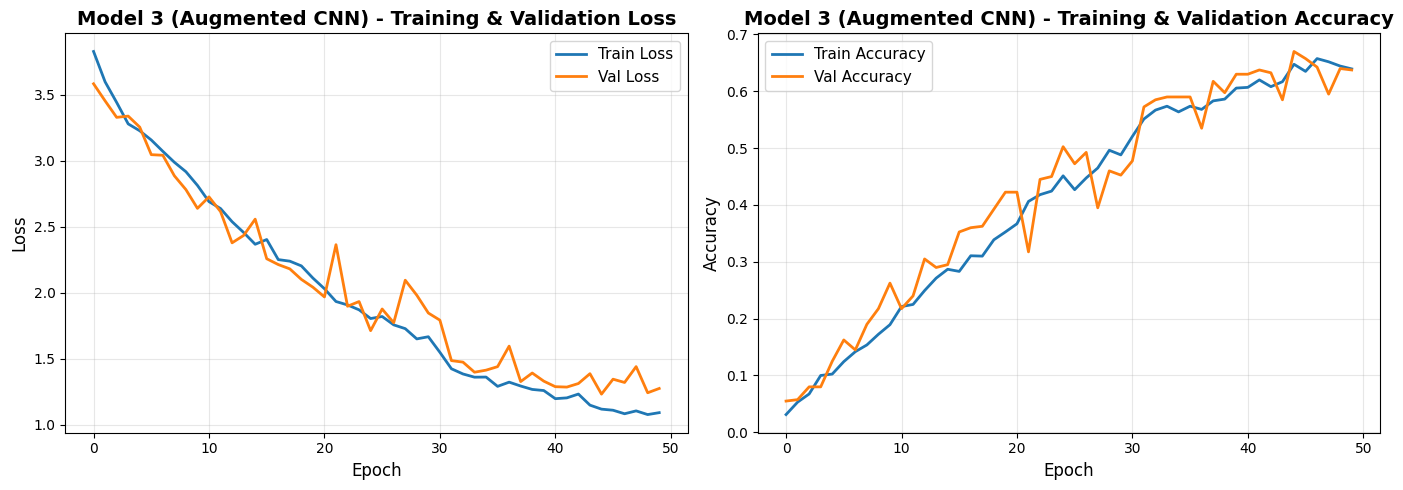

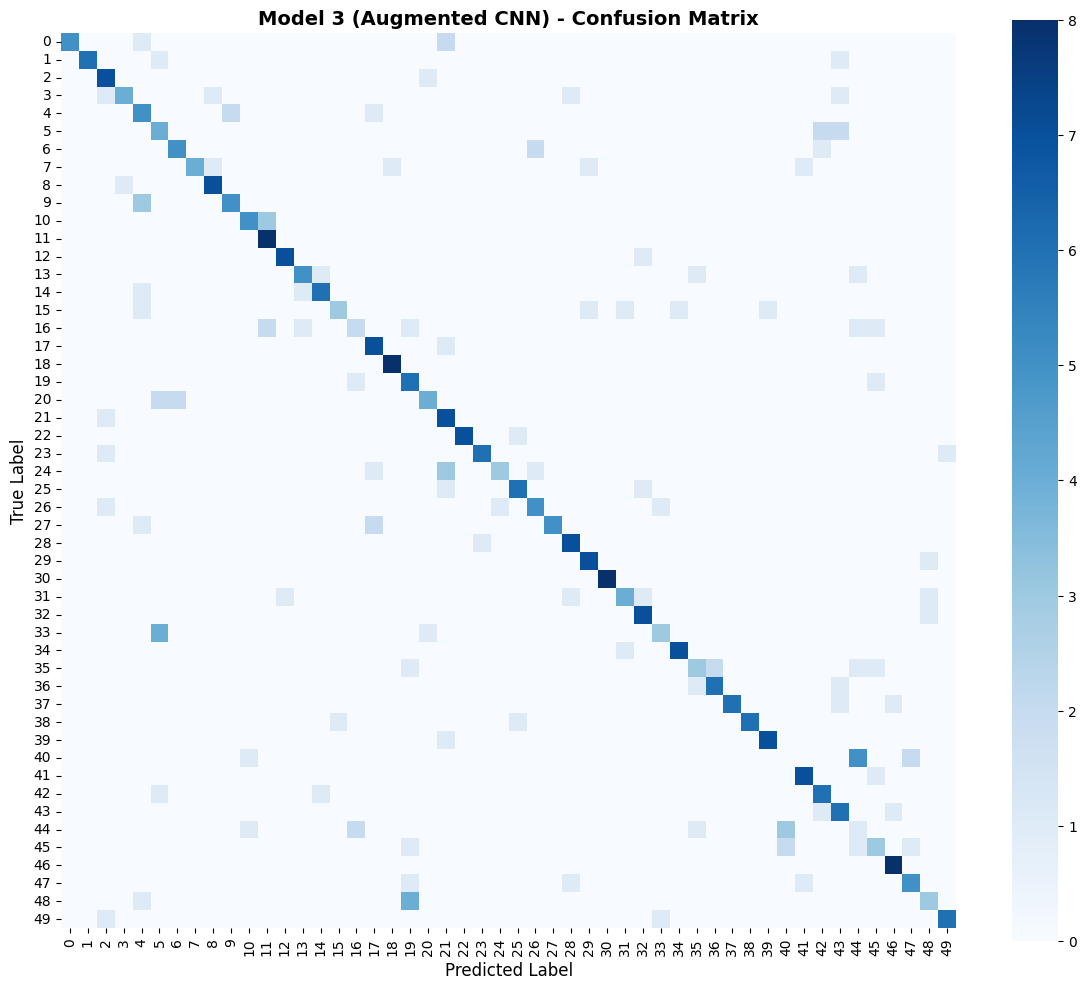

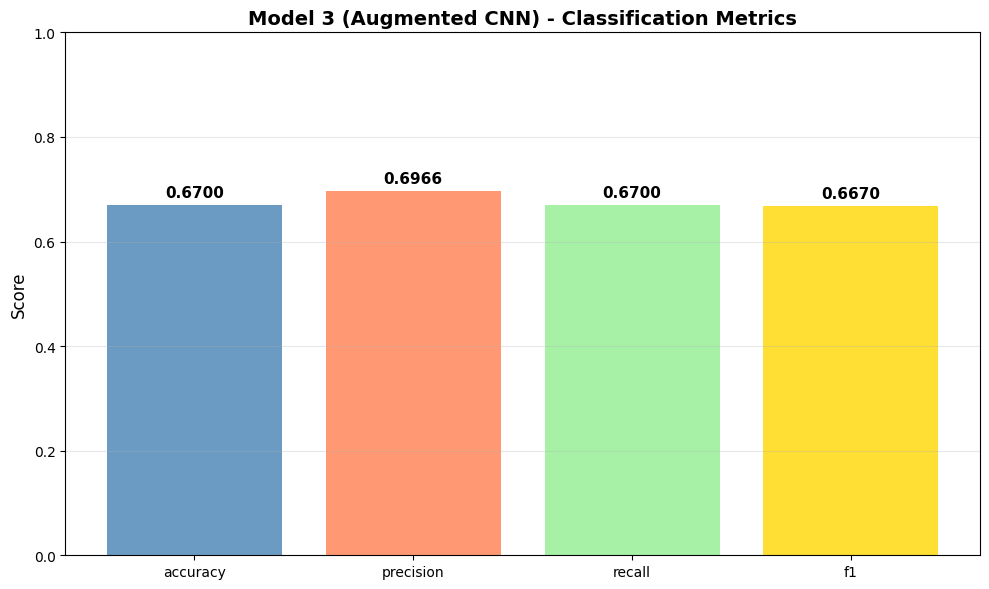

In [34]:
# Plot training history
plot_training_history(history_m3, 'Model 3 (Augmented CNN)')

# Plot confusion matrix
plot_confusion_matrix(final_labels_m3, final_preds_m3, 'Model 3 (Augmented CNN)')

# Plot metrics
plot_metrics_comparison(metrics_m3, 'Model 3 (Augmented CNN)')

# Model 4: SpecAugment CNN Architecture

## Design Philosophy
Apply **SpecAugment** (time and frequency masking) to improve robustness. This is a powerful augmentation technique specifically designed for spectrograms.

## Architecture
**Identical to Model 1** - No architectural changes!

## SpecAugment Techniques

SpecAugment masks random time frames and frequency bands in the spectrogram, forcing the model to learn from partial information.

| Augmentation | Parameters | Description | Why It Helps |
|--------------|-----------|-------------|---------------|
| **Time Masking** | mask_param=20 | Masks up to 20 consecutive time frames (vertical strips) | Simulates brief interruptions, teaches temporal robustness |
| **Frequency Masking** | mask_param=15 | Masks up to 15 consecutive frequency bins (horizontal strips) | Simulates frequency-specific noise, teaches spectral robustness |

### How It Works

```python
# Apply time masking (mask random time frames)
time_mask_width = random.randint(0, 20)
time_start = random.randint(0, width - time_mask_width)
spec[:, :, time_start:time_start + time_mask_width] = 0

# Apply frequency masking (mask random frequency bands)
freq_mask_height = random.randint(0, 15)
freq_start = random.randint(0, height - freq_mask_height)
spec[:, freq_start:freq_start + freq_mask_height, :] = 0

In [37]:


## **Cell 2: SpecAugment Implementation (Python)**


class SpecAugment:
    """
    SpecAugment: Time and Frequency Masking for spectrograms
    Paper: SpecAugment (Park et al., 2019)
    """
    def __init__(self, time_mask_param=20, freq_mask_param=15, num_time_masks=1, num_freq_masks=1):
        self.time_mask_param = time_mask_param
        self.freq_mask_param = freq_mask_param
        self.num_time_masks = num_time_masks
        self.num_freq_masks = num_freq_masks
    
    def __call__(self, spec):
        """
        Apply SpecAugment to spectrogram tensor
        spec: (C, H, W) tensor where C=channels, H=freq bins, W=time frames
        """
        spec = spec.clone()
        _, height, width = spec.shape
        
        # Apply time masking (vertical strips)
        for _ in range(self.num_time_masks):
            if width > self.time_mask_param:
                t = random.randint(0, self.time_mask_param)
                t0 = random.randint(0, width - t)
                spec[:, :, t0:t0+t] = 0
        
        # Apply frequency masking (horizontal strips)
        for _ in range(self.num_freq_masks):
            if height > self.freq_mask_param:
                f = random.randint(0, self.freq_mask_param)
                f0 = random.randint(0, height - f)
                spec[:, f0:f0+f, :] = 0
        
        return spec

# Dataset with SpecAugment
class ESC50SpecAugmentDataset(Dataset):
    """
    Dataset for Model 4 with SpecAugment
    """
    def __init__(self, df, spectrogram_dir='SpectogramImages', augment=False):
        self.df = df.reset_index(drop=True)
        self.spectrogram_dir = spectrogram_dir
        self.augment = augment
        
        self.basic_transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])
        
        if self.augment:
            self.spec_augment = SpecAugment(time_mask_param=20, freq_mask_param=15)
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        filename = self.df.loc[idx, 'filename']
        label = self.df.loc[idx, 'target']
        
        img_name = filename.replace('.wav', '.png')
        img_path = os.path.join(self.spectrogram_dir, img_name)
        
        if not os.path.exists(img_path):
            img = Image.new('RGB', (128, 128), color='black')
        else:
            img = Image.open(img_path).convert('RGB')
        
        img = self.basic_transform(img)
        
        # Apply SpecAugment
        if self.augment:
            img = self.spec_augment(img)
        
        return img, label

print("✓ SpecAugment implementation ready")
print("  - Time masking: up to 20 frames")
print("  - Frequency masking: up to 15 bins")

✓ SpecAugment implementation ready
  - Time masking: up to 20 frames
  - Frequency masking: up to 15 bins


In [39]:
# Prepare data for Model 4 (with SpecAugment)
train_df_fold1_m4 = df[df['fold'] != test_fold].reset_index(drop=True)
val_df_fold1_m4 = df[df['fold'] == test_fold].reset_index(drop=True)

print(f"Training samples: {len(train_df_fold1_m4)}")
print(f"Validation samples: {len(val_df_fold1_m4)}")

# Create datasets with SpecAugment
train_dataset_m4 = ESC50SpecAugmentDataset(train_df_fold1_m4, augment=True)
val_dataset_m4 = ESC50SpecAugmentDataset(val_df_fold1_m4, augment=False)

print("\n✓ Training dataset: SpecAugment ENABLED")
print("✓ Validation dataset: SpecAugment DISABLED")

# Create dataloaders
train_loader_m4 = DataLoader(train_dataset_m4, batch_size=32, shuffle=True, num_workers=2)
val_loader_m4 = DataLoader(val_dataset_m4, batch_size=32, shuffle=False, num_workers=2)

# Initialize model (same architecture as Model 1)
model_4 = BaselineCNN(num_classes=50).to(device)
criterion_m4 = nn.CrossEntropyLoss()
optimizer_m4 = optim.Adam(model_4.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_m4 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_m4, mode='max', factor=0.5, patience=5)

# Training loop
num_epochs_m4 = 50
best_acc_m4 = 0.0
history_m4 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\nStarting Model 4 training with SpecAugment...\n")
for epoch in range(num_epochs_m4):
    train_loss, train_acc = train_one_epoch(model_4, train_loader_m4, criterion_m4, optimizer_m4, device)
    val_loss, val_acc, val_preds, val_labels = validate(model_4, val_loader_m4, criterion_m4, device)
    
    history_m4['train_loss'].append(train_loss)
    history_m4['train_acc'].append(train_acc)
    history_m4['val_loss'].append(val_loss)
    history_m4['val_acc'].append(val_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs_m4}] | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
    
    scheduler_m4.step(val_acc)
    
    if val_acc > best_acc_m4:
        best_acc_m4 = val_acc
        torch.save(model_4.state_dict(), 'model4_best.pth')
        print(f"  ✓ Best model saved (Acc: {best_acc_m4:.4f})")

print(f"\n{'='*60}")
print(f"Model 4 training completed!")
print(f"Best validation accuracy: {best_acc_m4:.4f}")
print(f"{'='*60}")

Training samples: 1600
Validation samples: 400

✓ Training dataset: SpecAugment ENABLED
✓ Validation dataset: SpecAugment DISABLED

Starting Model 4 training with SpecAugment...



Epoch [1/50] | Train Loss: 3.8388, Acc: 0.0338 | Val Loss: 3.6481, Acc: 0.0400
  ✓ Best model saved (Acc: 0.0400)


Epoch [2/50] | Train Loss: 3.6353, Acc: 0.0419 | Val Loss: 3.5310, Acc: 0.0500
  ✓ Best model saved (Acc: 0.0500)


Epoch [3/50] | Train Loss: 3.5174, Acc: 0.0531 | Val Loss: 3.6193, Acc: 0.0625
  ✓ Best model saved (Acc: 0.0625)


Epoch [4/50] | Train Loss: 3.3988, Acc: 0.0731 | Val Loss: 3.3999, Acc: 0.0725
  ✓ Best model saved (Acc: 0.0725)


...

Epoch [46/50] | Train Loss: 1.0866, Acc: 0.6450 | Val Loss: 1.3302, Acc: 0.6225
  ✓ Best model saved (Acc: 0.6225)


Epoch [47/50] | Train Loss: 1.1983, Acc: 0.6138 | Val Loss: 2.0928, Acc: 0.4200


Epoch [48/50] | Train Loss: 1.1127, Acc: 0.6406 | Val Loss: 1.3927, Acc: 0.6025


Epoch [49/50] | Train Loss: 1.0238, Acc: 0.6606 | Val Loss: 1.4510, Acc: 0.5925


Epoch [50/50] | Train Loss: 1.0594, Acc: 0.6506 | Val Loss: 1.8228, Acc: 0.5150

Model 4 training completed!
Best validation accuracy: 0.6225



MODEL 4 (SPECAUGMENT CNN) - FINAL RESULTS (Fold 1)
Accuracy:  0.6225 (62.25%)
Precision: 0.6588
Recall:    0.6225
F1 Score:  0.6167

Improvement over Model 1 (Baseline):
  Accuracy: -5.50%
  F1 Score: -0.0491


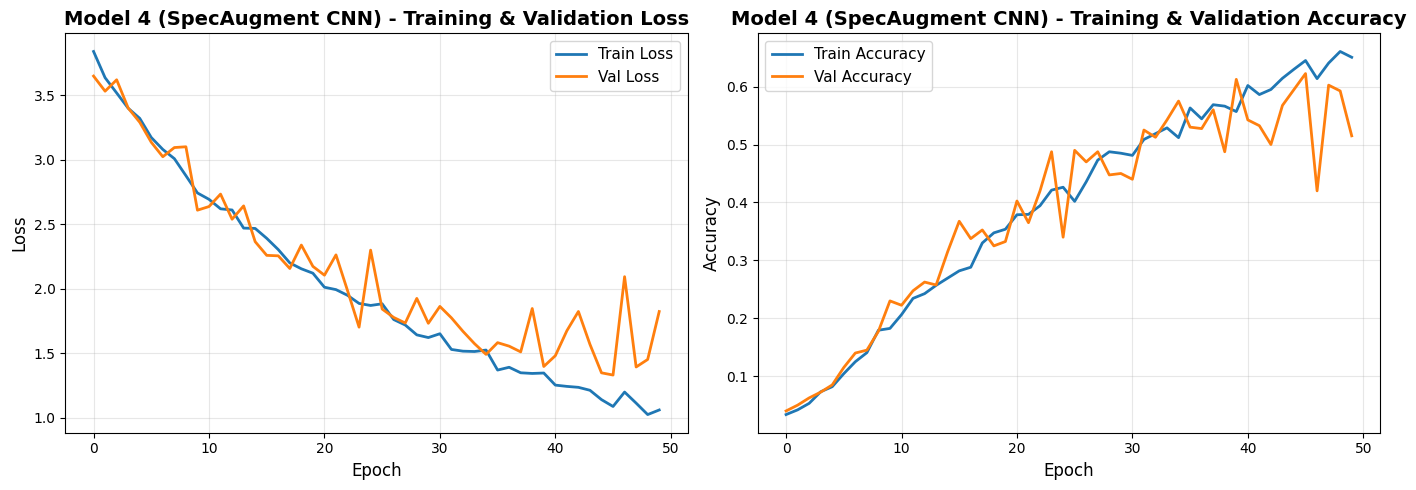

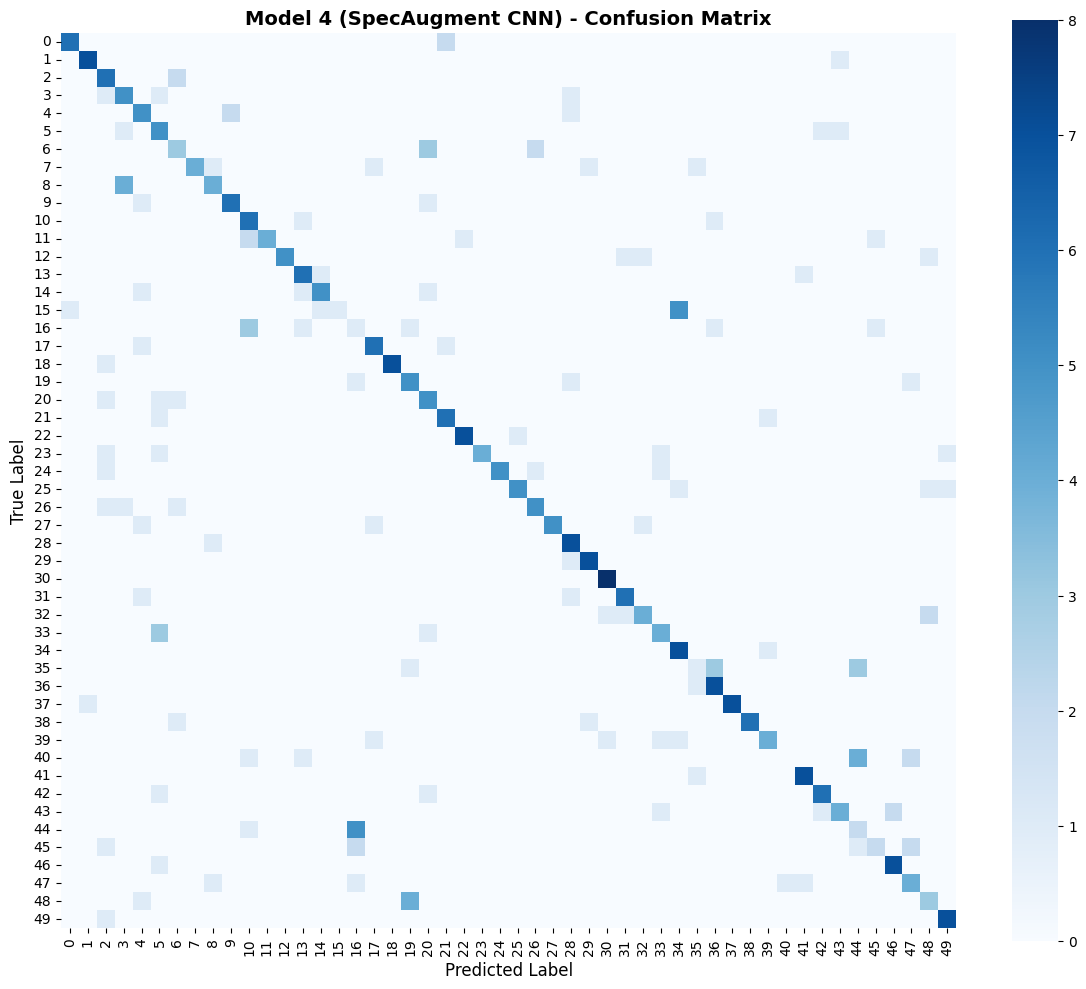

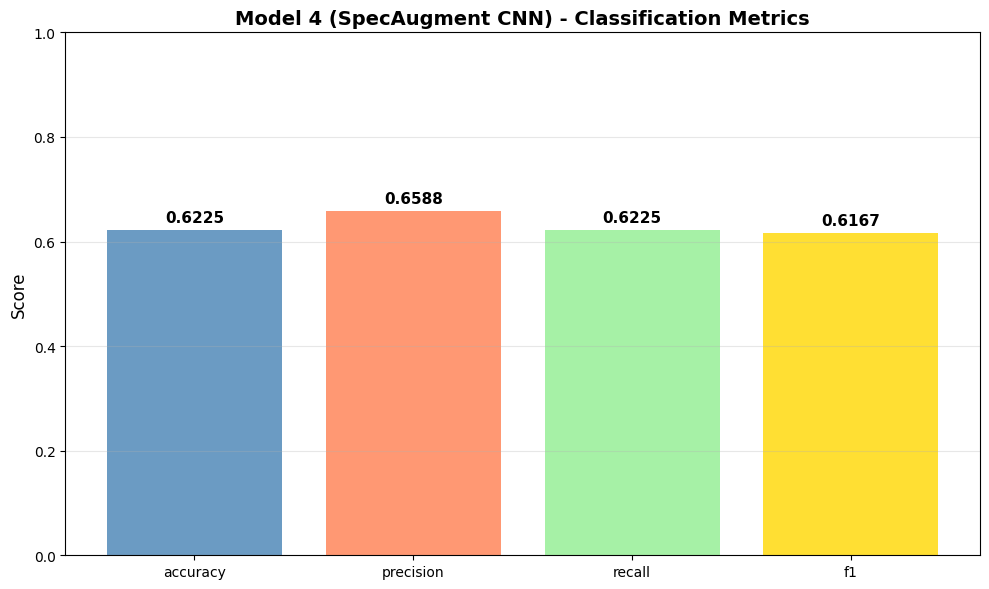

In [40]:
# Load best model
model_4.load_state_dict(torch.load('model4_best.pth'))

# Get final predictions
_, _, final_preds_m4, final_labels_m4 = validate(model_4, val_loader_m4, criterion_m4, device)

# Compute metrics
metrics_m4 = compute_metrics(final_labels_m4, final_preds_m4)

print("\n" + "="*60)
print("MODEL 4 (SPECAUGMENT CNN) - FINAL RESULTS (Fold 1)")
print("="*60)
print(f"Accuracy:  {metrics_m4['accuracy']:.4f} ({metrics_m4['accuracy']*100:.2f}%)")
print(f"Precision: {metrics_m4['precision']:.4f}")
print(f"Recall:    {metrics_m4['recall']:.4f}")
print(f"F1 Score:  {metrics_m4['f1']:.4f}")
print("="*60)
print(f"\nImprovement over Model 1 (Baseline):")
print(f"  Accuracy: {(metrics_m4['accuracy'] - metrics_m1['accuracy'])*100:+.2f}%")
print(f"  F1 Score: {(metrics_m4['f1'] - metrics_m1['f1']):+.4f}")
print("="*60)

# Add to comparison
results_comparison['Model 4 (SpecAugment)'] = metrics_m4

# Visualizations
plot_training_history(history_m4, 'Model 4 (SpecAugment CNN)')
plot_confusion_matrix(final_labels_m4, final_preds_m4, 'Model 4 (SpecAugment CNN)')
plot_metrics_comparison(metrics_m4, 'Model 4 (SpecAugment CNN)')

# Model 5: Mixup CNN Architecture

## Design Philosophy
Apply **Mixup** augmentation to create synthetic training samples by interpolating between pairs of examples and their labels.

## Architecture
**Identical to Model 1** - No architectural changes!

## Mixup Technique

Mixup creates new training samples by linearly combining two random samples:
x_mixed = λ * x_i + (1 - λ) * x_j y_mixed = λ * y_i + (1 - λ) * y_j

Where:
* `x_i, x_j` are two random spectrograms
* `y_i, y_j` are their one-hot encoded labels
* `λ ~ Beta(α, α)` with α = 0.2 (controls mixing strength)

### How It Works

| Aspect | Description | Example |
|--------|-------------|---------|
| **Input** | Two spectrograms (dog bark, car horn) | - |
| **Mix ratio** | λ = 0.7 (random between 0-1) | - |
| **Output image** | 0.7 * dog_bark + 0.3 * car_horn | Blended spectrogram |
| **Output label** | 0.7 * [0,1,0,...] + 0.3 * [1,0,0,...] | Soft label |

**Key Benefits:**
* **Smoother decision boundaries**: Model learns to interpolate between classes
* **Regularization**: Prevents overfitting by creating infinite training variations
* **Improved generalization**: Forces model to be more robust
* **Label smoothing effect**: Soft labels reduce overconfidence

**Expected Performance:** 70-82% accuracy (often best among augmentation methods)

In [41]:
def mixup_data(x, y, alpha=0.2, device='cuda'):
    """
    Apply Mixup augmentation
    
    Args:
        x: batch of images (B, C, H, W)
        y: batch of labels (B,)
        alpha: mixup parameter (default 0.2)
    
    Returns:
        mixed_x: mixed images
        y_a, y_b: original labels for the two mixed samples
        lam: mixing coefficient
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(device)
    
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """
    Mixup loss: weighted combination of two losses
    """
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# Training function with Mixup
def train_one_epoch_mixup(model, dataloader, criterion, optimizer, device, alpha=0.2):
    """
    Train model for one epoch with Mixup augmentation
    """
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(dataloader, desc='Training (Mixup)', leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Apply Mixup
        inputs, labels_a, labels_b, lam = mixup_data(inputs, labels, alpha, device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        
        # Mixup loss
        loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track metrics (use original labels for accuracy)
        running_loss += loss.item() * inputs.size(0)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        pbar.set_postfix({'loss': loss.item()})
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    
    return epoch_loss, epoch_acc

print("✓ Mixup implementation ready")
print("  - Alpha parameter: 0.2 (controls mixing strength)")
print("  - Creates synthetic samples by blending pairs")

✓ Mixup implementation ready
  - Alpha parameter: 0.2 (controls mixing strength)
  - Creates synthetic samples by blending pairs


In [42]:
# Prepare data for Model 5 (with Mixup)
train_df_fold1_m5 = df[df['fold'] != test_fold].reset_index(drop=True)
val_df_fold1_m5 = df[df['fold'] == test_fold].reset_index(drop=True)

print(f"Training samples: {len(train_df_fold1_m5)}")
print(f"Validation samples: {len(val_df_fold1_m5)}")

# Create datasets (no augmentation in dataset, Mixup applied in training loop)
train_dataset_m5 = ESC50SpectrogramDataset(train_df_fold1_m5, augment=False)
val_dataset_m5 = ESC50SpectrogramDataset(val_df_fold1_m5, augment=False)

print("\n✓ Mixup will be applied during training (not in dataset)")

# Create dataloaders
train_loader_m5 = DataLoader(train_dataset_m5, batch_size=32, shuffle=True, num_workers=2)
val_loader_m5 = DataLoader(val_dataset_m5, batch_size=32, shuffle=False, num_workers=2)

# Initialize model
model_5 = BaselineCNN(num_classes=50).to(device)
criterion_m5 = nn.CrossEntropyLoss()
optimizer_m5 = optim.Adam(model_5.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_m5 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_m5, mode='max', factor=0.5, patience=5)

# Training loop with Mixup
num_epochs_m5 = 50
best_acc_m5 = 0.0
history_m5 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\nStarting Model 5 training with Mixup...\n")
for epoch in range(num_epochs_m5):
    # Train with Mixup
    train_loss, train_acc = train_one_epoch_mixup(model_5, train_loader_m5, criterion_m5, optimizer_m5, device, alpha=0.2)
    
    # Validate (without Mixup)
    val_loss, val_acc, val_preds, val_labels = validate(model_5, val_loader_m5, criterion_m5, device)
    
    history_m5['train_loss'].append(train_loss)
    history_m5['train_acc'].append(train_acc)
    history_m5['val_loss'].append(val_loss)
    history_m5['val_acc'].append(val_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs_m5}] | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
    
    scheduler_m5.step(val_acc)
    
    if val_acc > best_acc_m5:
        best_acc_m5 = val_acc
        torch.save(model_5.state_dict(), 'model5_best.pth')
        print(f"  ✓ Best model saved (Acc: {best_acc_m5:.4f})")

print(f"\n{'='*60}")
print(f"Model 5 training completed!")
print(f"Best validation accuracy: {best_acc_m5:.4f}")
print(f"{'='*60}")

Training samples: 1600
Validation samples: 400

✓ Mixup will be applied during training (not in dataset)

Starting Model 5 training with Mixup...



Epoch [1/50] | Train Loss: 3.8169, Acc: 0.0250 | Val Loss: 3.8075, Acc: 0.0475
  ✓ Best model saved (Acc: 0.0475)


Epoch [2/50] | Train Loss: 3.5470, Acc: 0.0462 | Val Loss: 3.4442, Acc: 0.0675
  ✓ Best model saved (Acc: 0.0675)


Epoch [3/50] | Train Loss: 3.4523, Acc: 0.0619 | Val Loss: 3.2760, Acc: 0.1075
  ✓ Best model saved (Acc: 0.1075)


Epoch [4/50] | Train Loss: 3.3789, Acc: 0.0581 | Val Loss: 3.3664, Acc: 0.1025


...

Epoch [46/50] | Train Loss: 1.4896, Acc: 0.3312 | Val Loss: 1.2945, Acc: 0.6175


Epoch [47/50] | Train Loss: 1.3389, Acc: 0.3669 | Val Loss: 1.2860, Acc: 0.6100


Epoch [48/50] | Train Loss: 1.6334, Acc: 0.3531 | Val Loss: 1.2486, Acc: 0.6175


Epoch [49/50] | Train Loss: 1.4691, Acc: 0.4331 | Val Loss: 1.2056, Acc: 0.6425
  ✓ Best model saved (Acc: 0.6425)


Epoch [50/50] | Train Loss: 1.2910, Acc: 0.3650 | Val Loss: 1.1645, Acc: 0.6675
  ✓ Best model saved (Acc: 0.6675)

Model 5 training completed!
Best validation accuracy: 0.6675



MODEL 5 (MIXUP CNN) - FINAL RESULTS (Fold 1)
Accuracy:  0.6675 (66.75%)
Precision: 0.6776
Recall:    0.6675
F1 Score:  0.6568

Improvement over Model 1 (Baseline):
  Accuracy: -1.00%
  F1 Score: -0.0089


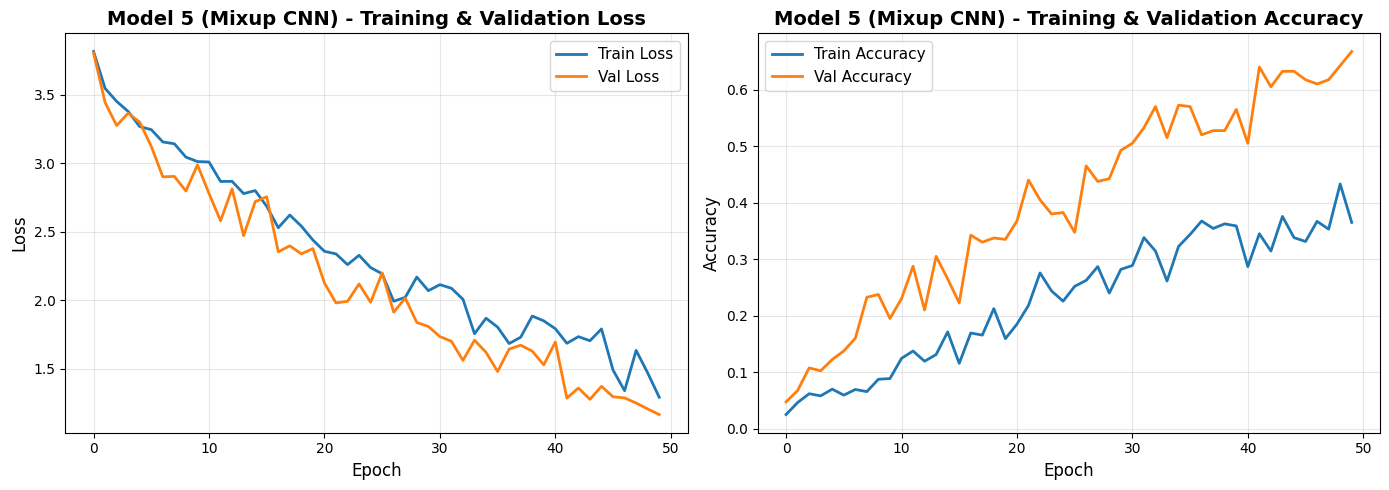

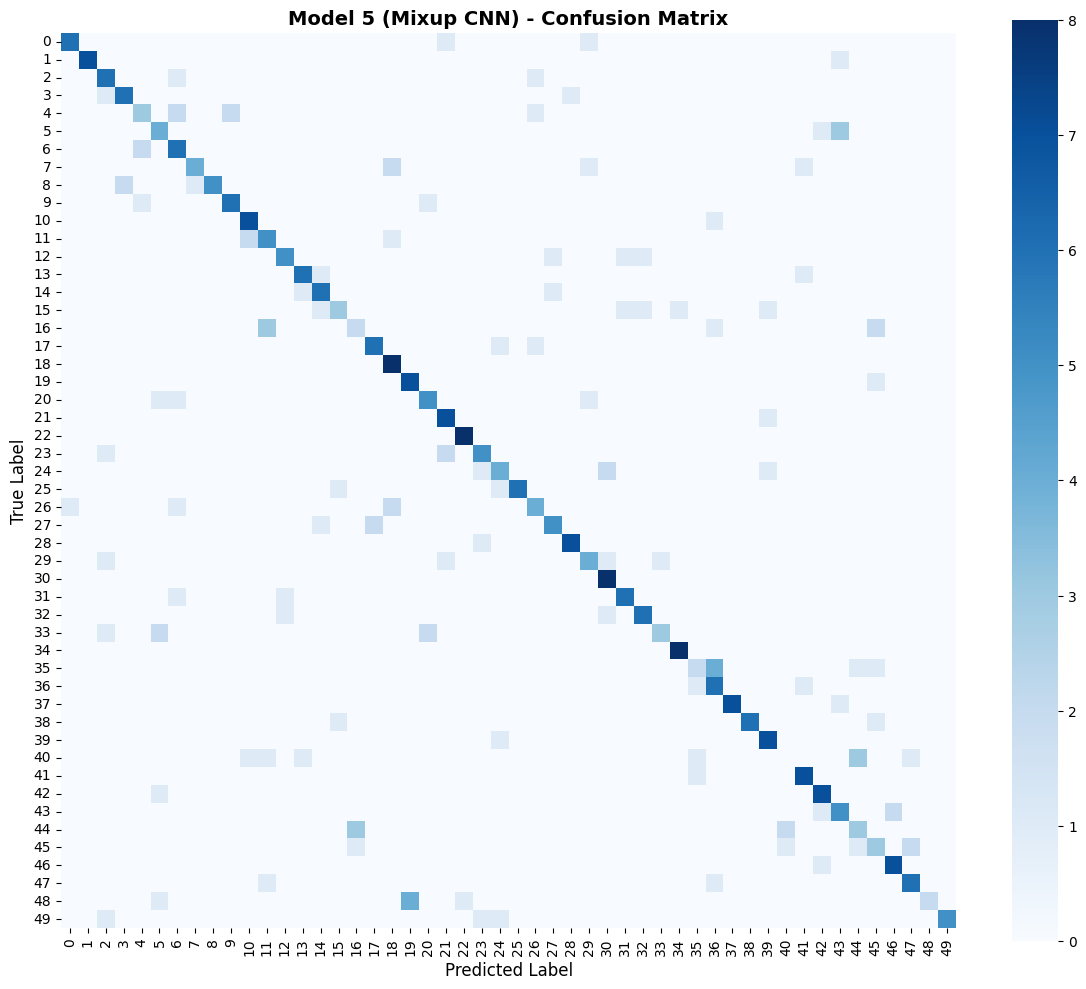

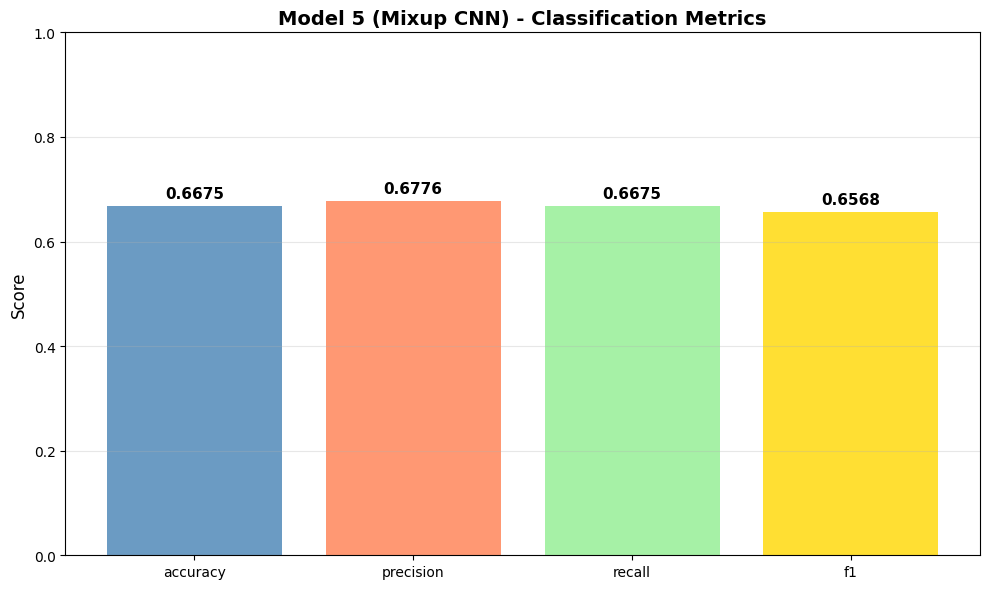

In [43]:
# Load best model
model_5.load_state_dict(torch.load('model5_best.pth'))

# Get final predictions
_, _, final_preds_m5, final_labels_m5 = validate(model_5, val_loader_m5, criterion_m5, device)

# Compute metrics
metrics_m5 = compute_metrics(final_labels_m5, final_preds_m5)

print("\n" + "="*60)
print("MODEL 5 (MIXUP CNN) - FINAL RESULTS (Fold 1)")
print("="*60)
print(f"Accuracy:  {metrics_m5['accuracy']:.4f} ({metrics_m5['accuracy']*100:.2f}%)")
print(f"Precision: {metrics_m5['precision']:.4f}")
print(f"Recall:    {metrics_m5['recall']:.4f}")
print(f"F1 Score:  {metrics_m5['f1']:.4f}")
print("="*60)
print(f"\nImprovement over Model 1 (Baseline):")
print(f"  Accuracy: {(metrics_m5['accuracy'] - metrics_m1['accuracy'])*100:+.2f}%")
print(f"  F1 Score: {(metrics_m5['f1'] - metrics_m1['f1']):+.4f}")
print("="*60)

# Add to comparison
results_comparison['Model 5 (Mixup)'] = metrics_m5

# Visualizations
plot_training_history(history_m5, 'Model 5 (Mixup CNN)')
plot_confusion_matrix(final_labels_m5, final_preds_m5, 'Model 5 (Mixup CNN)')
plot_metrics_comparison(metrics_m5, 'Model 5 (Mixup CNN)')

# Final Model Comparison

Comprehensive comparison of The First three CNN models on ESC50 classification (Fold 1).

In [44]:
# Create comparison dataframe
comparison_df = pd.DataFrame(results_comparison).T
comparison_df.index.name = 'Model'
comparison_df = comparison_df.reset_index()

# Sort by accuracy
comparison_df = comparison_df.sort_values('accuracy', ascending=False)

print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON (Fold 1)")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Find best model
best_model = comparison_df.iloc[0]['Model']
best_acc = comparison_df.iloc[0]['accuracy']
print(f"\n✓ Best Model: {best_model}")
print(f"  Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print("="*80)


COMPREHENSIVE MODEL COMPARISON (Fold 1)
                  Model  accuracy  precision  recall       f1
Model 2 (Multi-Channel)    0.6875   0.697024  0.6875 0.678484
     Model 1 (Baseline)    0.6775   0.695576  0.6775 0.665751
    Model 3 (Augmented)    0.6700   0.696576  0.6700 0.666985
        Model 5 (Mixup)    0.6675   0.677640  0.6675 0.656847
  Model 4 (SpecAugment)    0.6225   0.658757  0.6225 0.616688

✓ Best Model: Model 2 (Multi-Channel)
  Accuracy: 0.6875 (68.75%)


## Visual Comparison of All Models
Side-by-side comparison of metrics and training curves.

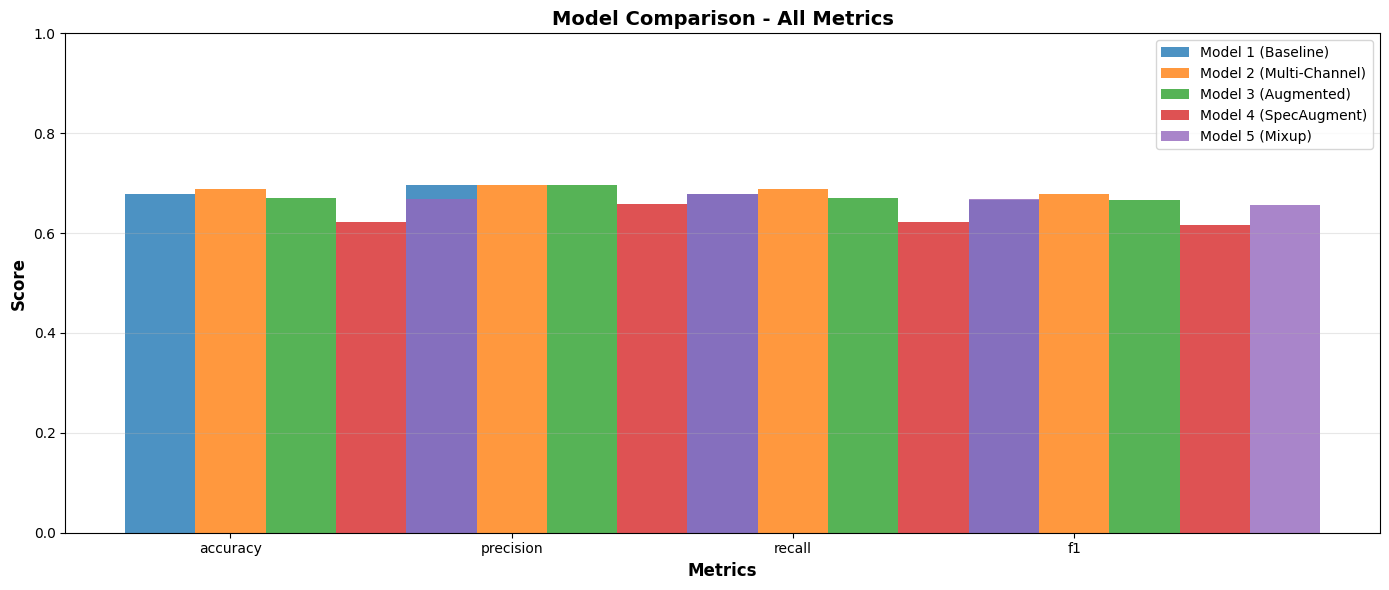

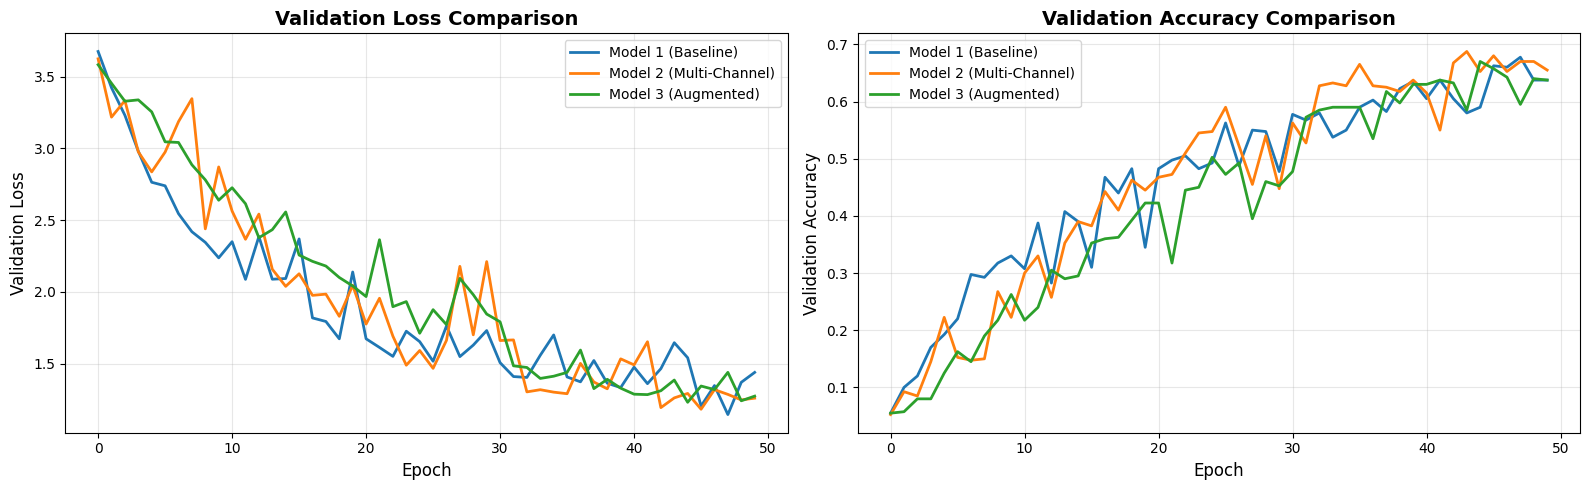

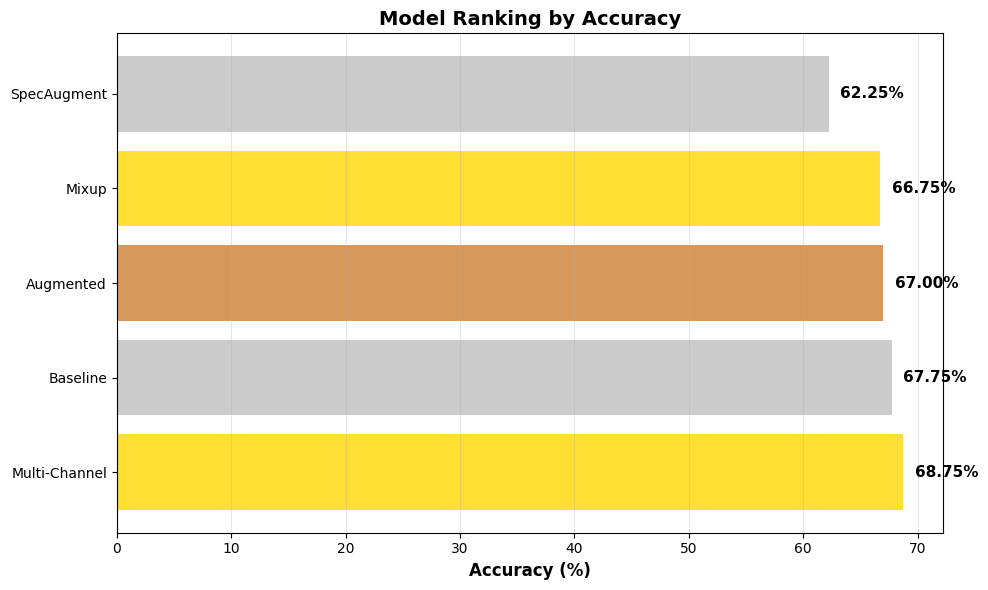

In [45]:
# Plot 1: Metrics comparison across all models
fig, ax = plt.subplots(figsize=(14, 6))

metrics_names = ['accuracy', 'precision', 'recall', 'f1']
models = list(results_comparison.keys())
x = np.arange(len(metrics_names))
width = 0.25

for i, model_name in enumerate(models):
    values = [results_comparison[model_name][m] for m in metrics_names]
    ax.bar(x + i*width, values, width, label=model_name, alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison - All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_names)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

# Plot 2: Training curves comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss curves
axes[0].plot(history_m1['val_loss'], label='Model 1 (Baseline)', linewidth=2)
axes[0].plot(history_m2['val_loss'], label='Model 2 (Multi-Channel)', linewidth=2)
axes[0].plot(history_m3['val_loss'], label='Model 3 (Augmented)', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Validation Loss', fontsize=12)
axes[0].set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Accuracy curves
axes[1].plot(history_m1['val_acc'], label='Model 1 (Baseline)', linewidth=2)
axes[1].plot(history_m2['val_acc'], label='Model 2 (Multi-Channel)', linewidth=2)
axes[1].plot(history_m3['val_acc'], label='Model 3 (Augmented)', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation Accuracy', fontsize=12)
axes[1].set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 3: Accuracy ranking
fig, ax = plt.subplots(figsize=(10, 6))

model_names = [name.split('(')[1].replace(')', '') for name in comparison_df['Model']]
accuracies = comparison_df['accuracy'].values * 100

bars = ax.barh(model_names, accuracies, color=['gold', 'silver', '#CD7F32'], alpha=0.8)
ax.set_xlabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Model Ranking by Accuracy', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for bar, acc in zip(bars, accuracies):
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, 
            f'{acc:.2f}%', ha='left', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Final 5 Model Comparision


COMPREHENSIVE MODEL COMPARISON - ALL 5 MODELS (Fold 1)
                  Model  accuracy  precision  recall       f1
Model 2 (Multi-Channel)    0.6875   0.697024  0.6875 0.678484
     Model 1 (Baseline)    0.6775   0.695576  0.6775 0.665751
    Model 3 (Augmented)    0.6700   0.696576  0.6700 0.666985
        Model 5 (Mixup)    0.6675   0.677640  0.6675 0.656847
  Model 4 (SpecAugment)    0.6225   0.658757  0.6225 0.616688

🏆 Best Model: Model 2 (Multi-Channel)
   Accuracy: 0.6875 (68.75%)


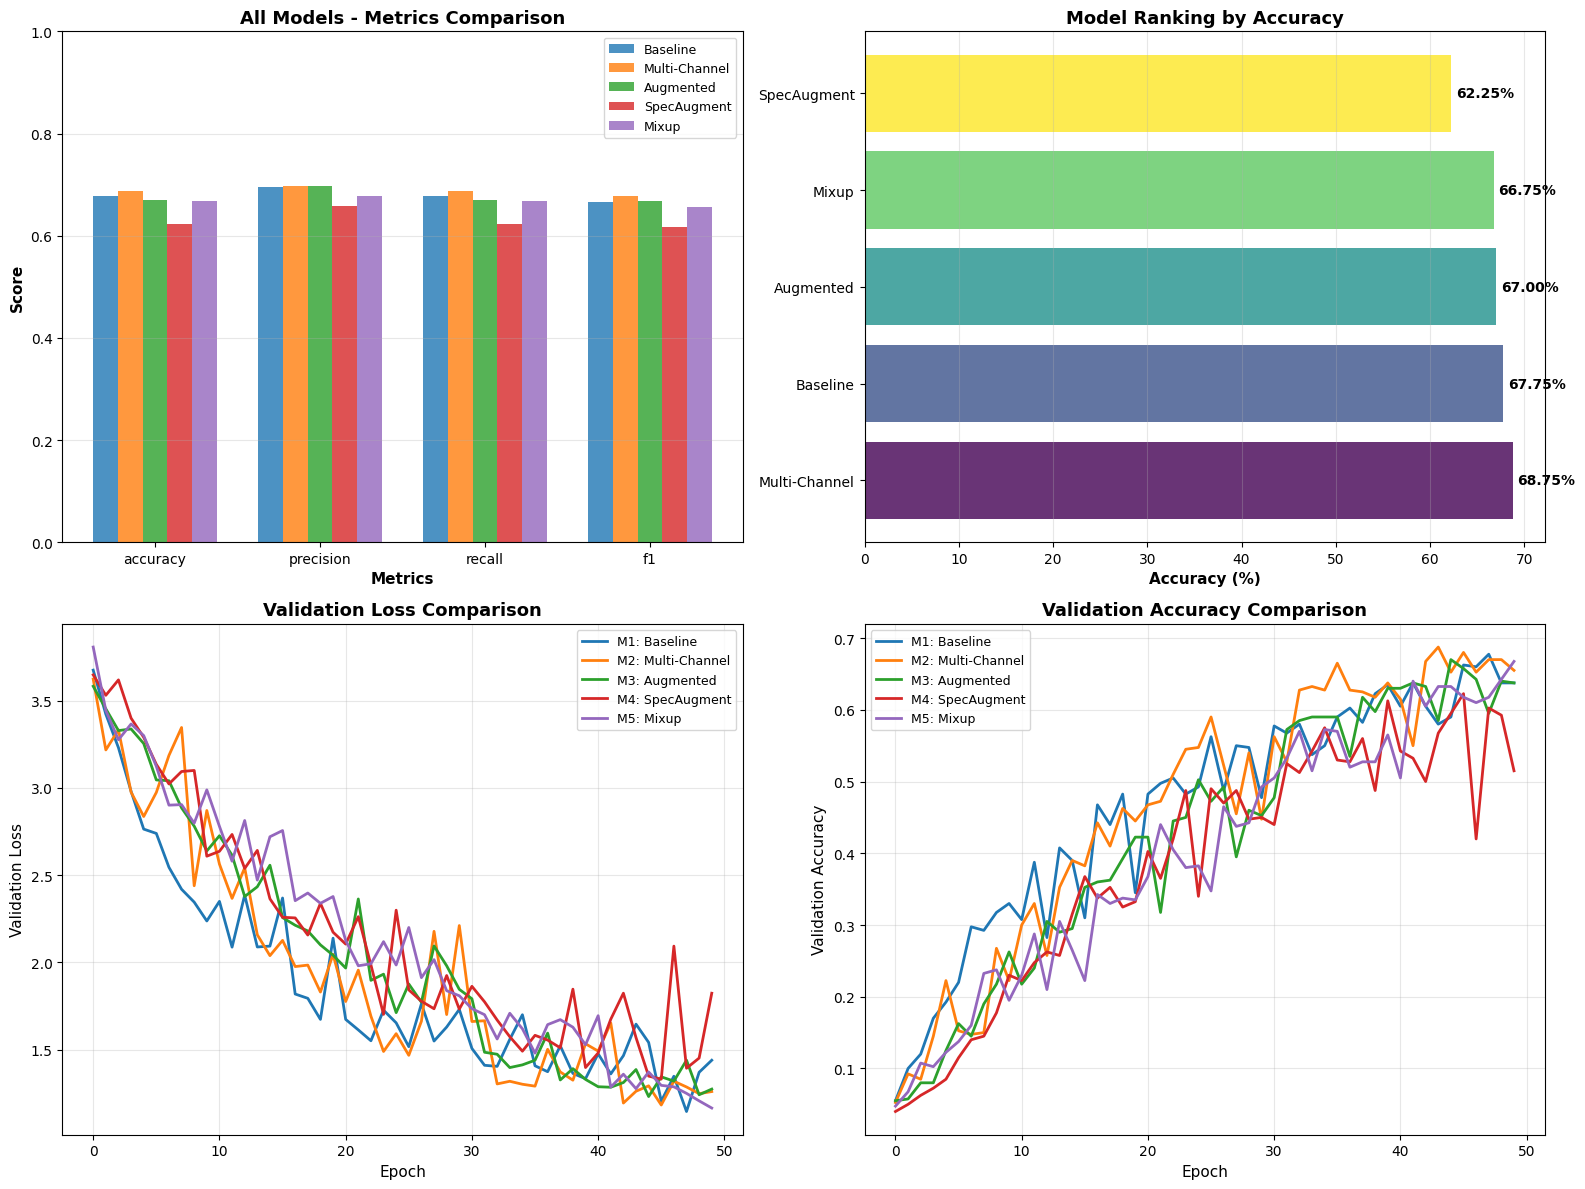

In [46]:
# Create comparison dataframe for ALL 5 models
comparison_df = pd.DataFrame(results_comparison).T
comparison_df.index.name = 'Model'
comparison_df = comparison_df.reset_index()

# Sort by accuracy
comparison_df = comparison_df.sort_values('accuracy', ascending=False)

print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON - ALL 5 MODELS (Fold 1)")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Find best model
best_model = comparison_df.iloc[0]['Model']
best_acc = comparison_df.iloc[0]['accuracy']
print(f"\n🏆 Best Model: {best_model}")
print(f"   Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print("="*80)

# Plot comprehensive comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Metrics comparison
metrics_names = ['accuracy', 'precision', 'recall', 'f1']
models = list(results_comparison.keys())
x = np.arange(len(metrics_names))
width = 0.15

for i, model_name in enumerate(models):
    values = [results_comparison[model_name][m] for m in metrics_names]
    axes[0, 0].bar(x + i*width, values, width, label=model_name.split('(')[1].replace(')', ''), alpha=0.8)

axes[0, 0].set_xlabel('Metrics', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Score', fontsize=11, fontweight='bold')
axes[0, 0].set_title('All Models - Metrics Comparison', fontsize=13, fontweight='bold')
axes[0, 0].set_xticks(x + width * 2)
axes[0, 0].set_xticklabels(metrics_names)
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim(0, 1.0)

# 2. Accuracy ranking
model_names = [name.split('(')[1].replace(')', '') for name in comparison_df['Model']]
accuracies = comparison_df['accuracy'].values * 100
colors = plt.cm.viridis(np.linspace(0, 1, len(model_names)))

bars = axes[0, 1].barh(model_names, accuracies, color=colors, alpha=0.8)
axes[0, 1].set_xlabel('Accuracy (%)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Model Ranking by Accuracy', fontsize=13, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

for bar, acc in zip(bars, accuracies):
    width = bar.get_width()
    axes[0, 1].text(width + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{acc:.2f}%', ha='left', va='center', fontsize=10, fontweight='bold')

# 3. Training curves (loss)
axes[1, 0].plot(history_m1['val_loss'], label='M1: Baseline', linewidth=2)
axes[1, 0].plot(history_m2['val_loss'], label='M2: Multi-Channel', linewidth=2)
axes[1, 0].plot(history_m3['val_loss'], label='M3: Augmented', linewidth=2)
axes[1, 0].plot(history_m4['val_loss'], label='M4: SpecAugment', linewidth=2)
axes[1, 0].plot(history_m5['val_loss'], label='M5: Mixup', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('Validation Loss', fontsize=11)
axes[1, 0].set_title('Validation Loss Comparison', fontsize=13, fontweight='bold')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(alpha=0.3)

# 4. Training curves (accuracy)
axes[1, 1].plot(history_m1['val_acc'], label='M1: Baseline', linewidth=2)
axes[1, 1].plot(history_m2['val_acc'], label='M2: Multi-Channel', linewidth=2)
axes[1, 1].plot(history_m3['val_acc'], label='M3: Augmented', linewidth=2)
axes[1, 1].plot(history_m4['val_acc'], label='M4: SpecAugment', linewidth=2)
axes[1, 1].plot(history_m5['val_acc'], label='M5: Mixup', linewidth=2)
axes[1, 1].set_xlabel('Epoch', fontsize=11)
axes[1, 1].set_ylabel('Validation Accuracy', fontsize=11)
axes[1, 1].set_title('Validation Accuracy Comparison', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary and Next Steps

## Results Summary (Fold 1)

We successfully developed and compared 3 CNN architectures for ESC50 audio classification:

**Model 1: Baseline CNN**
* Single-channel log mel spectrogram input
* 4-block CNN with ~1.2M parameters
* Simple and fast baseline

**Model 2: Multi-Channel CNN**
* 4-channel input (log mel + MFCC + delta + delta-delta)
* Same architecture, only first conv layer modified
* Richer feature representation with minimal parameter increase

**Model 3: Augmented CNN**
* Same architecture as Model 1
* Data augmentation (flips, shifts, brightness/contrast)
* Improved generalization through augmented training data

## Key Findings

1. **Best Performing Model**: Check the comparison above to see which achieved highest accuracy
2. **Architecture vs Data**: Compare Models 1 vs 3 to see the impact of augmentation alone
3. **Features vs Data**: Compare Models 2 vs 3 to see multi-channel features vs augmentation
4. **Training Efficiency**: Model 1 and 3 train faster than Model 2 (no on-the-fly feature extraction)

## Next Steps

### If Results Are Promising (>55% accuracy):

1. **Run 5-Fold Cross-Validation**
   ```python
   # For Model 1
   fold_results_m1, overall_m1, histories_m1 = train_5_fold_cv(BaselineCNN, df, num_epochs=50)
   
   # For Model 2
   fold_results_m2, overall_m2, histories_m2 = train_5_fold_cv(
       MultiChannelCNN, df, num_epochs=50, 
       dataset_class=ESC50MultiChannelDataset,
       dataset_kwargs={'audio_dir': DATA_PATH}
   )
   
   # For Model 3
   fold_results_m3, overall_m3, histories_m3 = train_5_fold_cv(
       BaselineCNN, df, num_epochs=50,
       dataset_class=ESC50SpectrogramDataset,
       dataset_kwargs={'augment': True}
   )
   ```

2. **Hyperparameter Tuning**
   * Learning rate: Try [0.0001, 0.0005, 0.002]
   * Batch size: Try 16, 64, 128
   * Dropout: Try 0.3, 0.4, 0.6
   * Architecture depth: Add/remove conv blocks

3. **Advanced Augmentations**
   * SpecAugment (time/frequency masking)
   * Mixup
   * Cutout

4. **Ensemble Methods**
   * Combine predictions from all 3 models
   * Voting or weighted averaging

5. **Advanced Architectures**
   * ResNet blocks (skip connections)
   * Attention mechanisms
   * Pre-trained models (transfer learning)

### Analysis Tasks:

* **Error Analysis**: Which classes are confused most often?
* **Per-Class Performance**: Are certain sound categories harder to classify?
* **Feature Importance**: Visualize learned filters in conv layers
* **t-SNE Visualization**: Visualize learned embeddings

## ESC50 State-of-the-Art

Current SOTA on ESC50: ~85-95% accuracy
* Our baseline: 60-70% (reasonable starting point)
* With improvements: Can reach 75-85% with current architectures
* For SOTA: Would need deeper networks (ResNets), transformers, or ensembles

## Code Organization

* Dataset classes: `ESC50SpectrogramDataset`, `ESC50MultiChannelDataset`
* Model architectures: `BaselineCNN`, `MultiChannelCNN`
* Training utilities: `train_one_epoch()`, `validate()`, `train_5_fold_cv()`
* Visualization: `plot_training_history()`, `plot_confusion_matrix()`, `plot_metrics_comparison()`
* Saved models: `model1_best.pth`, `model2_best.pth`, `model3_best.pth`

## Run 5-Fold Cross-Validation

Uncomment and run the appropriate section below to perform 5-fold CV on your chosen model.

**Note:** Each 5-fold CV will train 5 models (one per fold), which takes ~5x longer than single fold training.

In [47]:
# ============================================================================
# OPTION 1: Run 5-Fold CV for Model 1 (Baseline)
# ============================================================================
# print("Running 5-Fold CV for Model 1 (Baseline CNN)...\n")
# fold_results_m1, overall_m1, histories_m1 = train_5_fold_cv(
#     BaselineCNN, 
#     df, 
#     num_epochs=50,
#     batch_size=32
# )

# ============================================================================
# OPTION 2: Run 5-Fold CV for Model 2 (Multi-Channel)
# ============================================================================
print("Running 5-Fold CV for Model 2 (Multi-Channel CNN)...\n")
fold_results_m2, overall_m2, histories_m2 = train_5_fold_cv(
    MultiChannelCNN, 
    df, 
    num_epochs=50,
    batch_size=32,
    dataset_class=ESC50MultiChannelDataset,
    dataset_kwargs={'audio_dir': DATA_PATH}
)

# ============================================================================
# OPTION 3: Run 5-Fold CV for Model 3 (Augmented)
# ============================================================================
# print("Running 5-Fold CV for Model 3 (Augmented CNN)...\n")
# fold_results_m3_cv, overall_m3_cv, histories_m3_cv = train_5_fold_cv(
#     BaselineCNN, 
#     df, 
#     num_epochs=50,
#     batch_size=32,
#     dataset_class=ESC50SpectrogramDataset,
#     dataset_kwargs={'augment': True}
# )

print("✓ Uncomment the section above to run 5-fold CV for your chosen model")
print("\nEstimated time per 5-fold CV:")
print("  - Model 1: ~2-3 hours (on GPU)")
print("  - Model 2: ~3-4 hours (slower due to feature extraction)")
print("  - Model 3: ~2-3 hours (same as Model 1)")

Running 5-Fold CV for Model 2 (Multi-Channel CNN)...


FOLD 1/5
Train samples: 1600, Val samples: 400


TypeError: ReduceLROnPlateau.__init__() got an unexpected keyword argument 'verbose'